In [ ]:
%pip install -U pylatexenc

In [ ]:
%pip install -U qiskit qiskit-ibm-runtime matplotlib pylatexenc

In [ ]:
%pip install -U pylatexenc

In [ ]:
%pip install -U qiskit-ibm-runtime

In [ ]:

pip install qiskit qiskit-aer

In [ ]:
from google.colab import userdata

token_ibm = userdata.get("IBM_QUANTUM_TOKEN")
crn_ibm = userdata.get("IBM_QUANTUM_CRN")

print("Token encontrado:", bool(token_ibm))
print("CRN encontrado:", bool(crn_ibm))

Token encontrado: True
CRN encontrado: True


In [ ]:
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService

token_ibm = userdata.get("IBM_QUANTUM_TOKEN")
crn_ibm = userdata.get("IBM_QUANTUM_CRN")

if not token_ibm:
    raise ValueError("O secret IBM_QUANTUM_TOKEN não foi encontrado.")

if not crn_ibm:
    raise ValueError("O secret IBM_QUANTUM_CRN não foi encontrado.")

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token_ibm,
    instance=crn_ibm
)

print("Conectado à instância IBM Quantum!")
print("Instância ativa:", service.active_instance())

backend = service.least_busy(
    operational=True,
    simulator=False
)

print("QPU real selecionada:", backend.name)
print("Quantidade de qubits:", backend.num_qubits)

qiskit_runtime_service._discover_account:WARNING:2026-07-16 21:01:53,954: Loading account with the given token. A saved account will not be used.


Conectado à instância IBM Quantum!
Instância ativa: crn:v1:bluemix:public:quantum-computing:us-east:a/83888cb80a84405780972693753bdfc3:cfe036fd-33f9-4d20-b9d2-d8dbf168d8e5::
QPU real selecionada: ibm_marrakesh
Quantidade de qubits: 156


qiskit_runtime_service._discover_account:WARNING:2026-07-16 21:11:07,322: Loading account with the given token. A saved account will not be used.


Conectado à IBM Quantum!
QPU escolhida: ibm_marrakesh
ID do trabalho: d9ckhsphtsac739bsg90
O circuito foi enviado para a fila da QPU.

Resultados:
Quantidade de execuções: 1000
Quantidade de zeros: 483
Quantidade de uns: 517
Probabilidade de 0: 48.30%
Probabilidade de 1: 51.70%


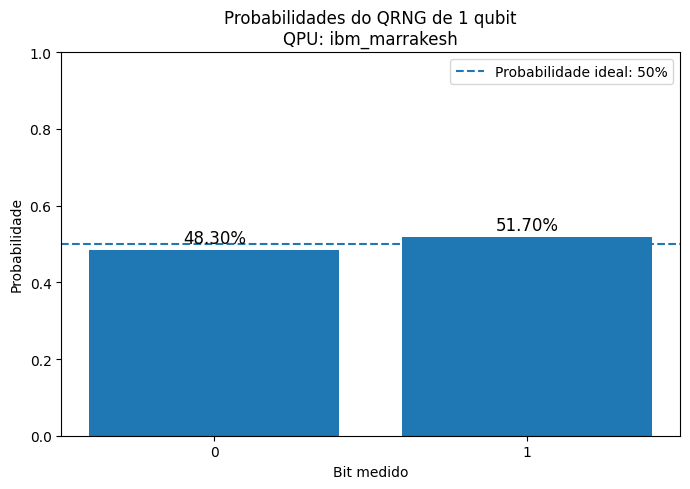

In [ ]:
from google.colab import userdata

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

import matplotlib.pyplot as plt


# 1. Conexão com a IBM Quantum

token_ibm = userdata.get("IBM_QUANTUM_TOKEN")
crn_ibm = userdata.get("IBM_QUANTUM_CRN")

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token_ibm,
    instance=crn_ibm
)

print("Conectado à IBM Quantum!")


# 2. Escolha de uma QPU real

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=1
)

print("QPU escolhida:", backend.name)


# 3. Construção do QRNG de 1 qubit

circuito = QuantumCircuit(1, 1)

# O qubit começa no estado |0>
# A porta Hadamard cria uma superposição entre |0> e |1>
circuito.h(0)

# Mede o qubit 0 e salva o resultado no bit clássico 0
circuito.measure(0, 0)


# 4. Transpilação para a QPU escolhida

pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

circuito_isa = pass_manager.run(circuito)


# 5. Execução na QPU real

sampler = SamplerV2(mode=backend)

quantidade_execucoes = 1000

job = sampler.run(
    [circuito_isa],
    shots=quantidade_execucoes
)

print("ID do trabalho:", job.job_id())
print("O circuito foi enviado para a fila da QPU.")


# 6. Obtenção dos resultados

resultado = job.result()

dados = resultado[0].data

# O registrador clássico criado pelo QuantumCircuit(1, 1)
# possui, normalmente, o nome "c"
bits_medidos = dados.c.get_bitstrings()


# 7. Contagem dos bits

quantidade_zeros = bits_medidos.count("0")
quantidade_uns = bits_medidos.count("1")


# 8. Cálculo das probabilidades experimentais

total_resultados = len(bits_medidos)

probabilidade_zero = quantidade_zeros / total_resultados
probabilidade_um = quantidade_uns / total_resultados


print("\nResultados:")
print("Quantidade de execuções:", total_resultados)
print("Quantidade de zeros:", quantidade_zeros)
print("Quantidade de uns:", quantidade_uns)
print(f"Probabilidade de 0: {probabilidade_zero:.2%}")
print(f"Probabilidade de 1: {probabilidade_um:.2%}")


# 9. Gráfico das probabilidades

bits = ["0", "1"]
probabilidades = [probabilidade_zero, probabilidade_um]

plt.figure(figsize=(7, 5))

barras = plt.bar(
    bits,
    probabilidades
)

plt.title(
    f"Probabilidades do QRNG de 1 qubit\n"
    f"QPU: {backend.name}"
)

plt.xlabel("Bit medido")
plt.ylabel("Probabilidade")
plt.ylim(0, 1)

# Linha indicando a probabilidade ideal de 50%
plt.axhline(
    y=0.5,
    linestyle="--",
    label="Probabilidade ideal: 50%"
)

# Escreve o valor acima de cada barra
for barra, probabilidade in zip(barras, probabilidades):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        probabilidade + 0.02,
        f"{probabilidade:.2%}",
        ha="center",
        fontsize=12
    )

plt.legend()
plt.tight_layout()
plt.show()

qiskit_runtime_service._discover_account:WARNING:2026-07-24 18:35:16,264: Loading account with the given token. A saved account will not be used.


Conectado à IBM Quantum!
QPU escolhida: ibm_marrakesh
Quantidade de qubits utilizados: 3
ID do trabalho: d9hr0s8gk0ls73f3ei80
O circuito foi enviado para a fila da QPU.

Resultados:
000: 113 ocorrências — 11.30%
001: 114 ocorrências — 11.40%
010: 114 ocorrências — 11.40%
011: 124 ocorrências — 12.40%
100: 121 ocorrências — 12.10%
101: 136 ocorrências — 13.60%
110: 147 ocorrências — 14.70%
111: 131 ocorrências — 13.10%


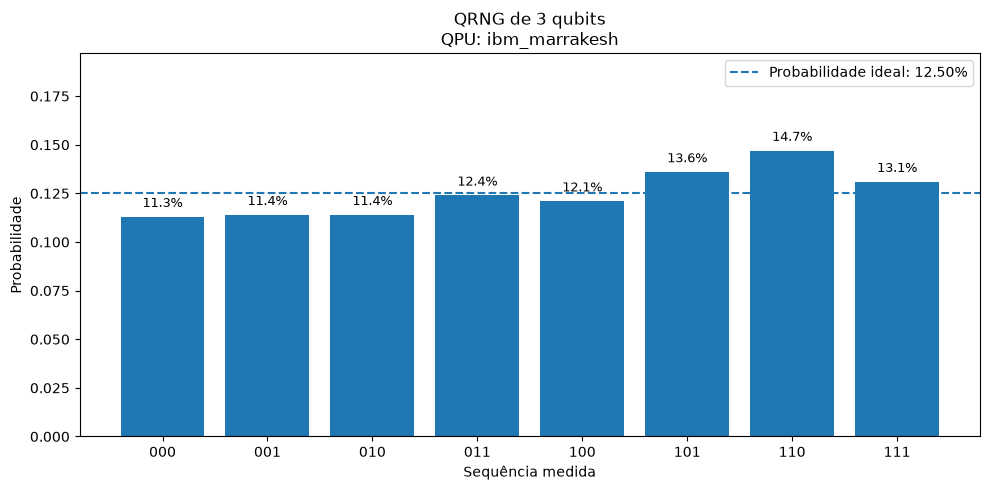

In [ ]:
#Para N bits

from google.colab import userdata

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. Conexão com a IBM Quantum
# --------------------------------------------------

token_ibm = userdata.get("IBM_QUANTUM_TOKEN")
crn_ibm = userdata.get("IBM_QUANTUM_CRN")

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token_ibm,
    instance=crn_ibm
)

print("Conectado à IBM Quantum!")


# --------------------------------------------------
# 2. Quantidade de qubits
# --------------------------------------------------

numero_qubits = 3

if numero_qubits <= 0:
    raise ValueError("O número de qubits deve ser maior que zero.")


# --------------------------------------------------
# 3. Escolha de uma QPU real
# --------------------------------------------------

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=numero_qubits
)

print("QPU escolhida:", backend.name)
print("Quantidade de qubits utilizados:", numero_qubits)


# --------------------------------------------------
# 4. Construção do QRNG de N qubits
# --------------------------------------------------

circuito = QuantumCircuit(numero_qubits, numero_qubits)

for qubit in range(numero_qubits):
    circuito.h(qubit)

for qubit in range(numero_qubits):
    circuito.measure(qubit, qubit)


# --------------------------------------------------
# 5. Transpilação para a QPU
# --------------------------------------------------

pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

circuito_isa = pass_manager.run(circuito)


# --------------------------------------------------
# 6. Execução na QPU real
# --------------------------------------------------

sampler = SamplerV2(mode=backend)

quantidade_execucoes = 1000

job = sampler.run(
    [circuito_isa],
    shots=quantidade_execucoes
)

print("ID do trabalho:", job.job_id())
print("O circuito foi enviado para a fila da QPU.")


# --------------------------------------------------
# 7. Obtenção dos resultados
# --------------------------------------------------

resultado = job.result()

dados = resultado[0].data

sequencias_medidas = dados.c.get_bitstrings()


# --------------------------------------------------
# 8. Contagem das sequências
# --------------------------------------------------

contagens = {}

for sequencia in sequencias_medidas:
    if sequencia not in contagens:
        contagens[sequencia] = 0

    contagens[sequencia] += 1


# Ordena as sequências
sequencias = sorted(contagens.keys())

probabilidades = []

for sequencia in sequencias:
    probabilidade = contagens[sequencia] / quantidade_execucoes
    probabilidades.append(probabilidade)


# --------------------------------------------------
# 9. Exibição dos resultados
# --------------------------------------------------

print("\nResultados:")

for sequencia, probabilidade in zip(sequencias, probabilidades):
    print(
        f"{sequencia}: "
        f"{contagens[sequencia]} ocorrências — "
        f"{probabilidade:.2%}"
    )


# --------------------------------------------------
# 10. Gráfico
# --------------------------------------------------

plt.figure(figsize=(10, 5))

barras = plt.bar(
    sequencias,
    probabilidades
)

probabilidade_ideal = 1 / (2 ** numero_qubits)

plt.axhline(
    y=probabilidade_ideal,
    linestyle="--",
    label=f"Probabilidade ideal: {probabilidade_ideal:.2%}"
)

plt.title(
    f"QRNG de {numero_qubits} qubits\n"
    f"QPU: {backend.name}"
)

plt.xlabel("Sequência medida")
plt.ylabel("Probabilidade")

plt.ylim(
    0,
    max(probabilidades) + 0.05
)

for barra, probabilidade in zip(barras, probabilidades):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        probabilidade + 0.005,
        f"{probabilidade:.1%}",
        ha="center",
        fontsize=9
    )

plt.legend()
plt.tight_layout()
plt.show()

qiskit_runtime_service._discover_account:WARNING:2026-07-16 21:32:27,584: Loading account with the given token. A saved account will not be used.


Conectado à IBM Quantum!
Qubits utilizados: 8
Execuções necessárias: 1251
Bits que serão produzidos antes do corte: 10008
QPU escolhida: ibm_marrakesh
ID do trabalho: d9ckrt4jeosc73fgdmu0
O circuito foi enviado para a fila da QPU.

Primeiros 100 bits:
1101010100100010011011111111101001110110010111100011111101011010110100011001001110011110011111110010

Total de bits gerados: 10001

Resultados:
Quantidade de zeros: 4987
Quantidade de uns: 5014
Probabilidade de 0: 49.8650%
Probabilidade de 1: 50.1350%


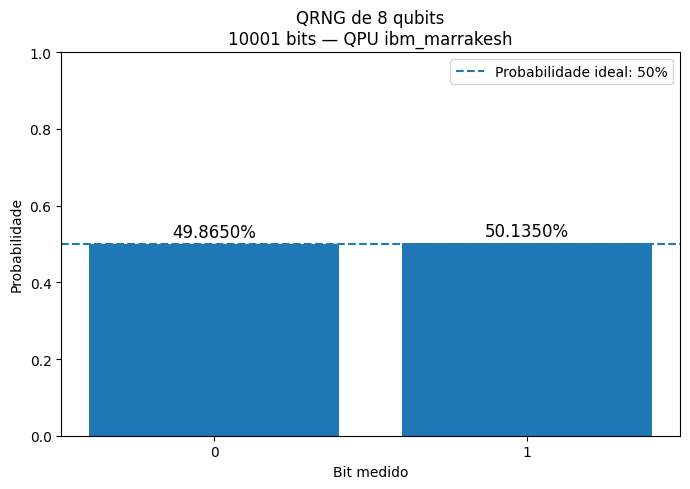

In [ ]:
from google.colab import userdata

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

import math
import matplotlib.pyplot as plt

# 1. Conexão com a IBM Quantum

token_ibm = userdata.get("IBM_QUANTUM_TOKEN")
crn_ibm = userdata.get("IBM_QUANTUM_CRN")

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token_ibm,
    instance=crn_ibm
)

print("Conectado à IBM Quantum!")

# 2. Configurações
numero_qubits = 8

# Quantidade mínima de bits desejada
quantidade_bits_desejada = 10_001

if numero_qubits <= 0:
    raise ValueError("O número de qubits deve ser maior que zero.")

if quantidade_bits_desejada <= 10_000:
    raise ValueError("A quantidade desejada deve ser maior que 10.000 bits.")


# Calcula quantas execuções são necessárias
quantidade_execucoes = math.ceil(
    quantidade_bits_desejada / numero_qubits
)

print("Qubits utilizados:", numero_qubits)
print("Execuções necessárias:", quantidade_execucoes)
print(
    "Bits que serão produzidos antes do corte:",
    numero_qubits * quantidade_execucoes
)

# 3. Escolha de uma QPU real
backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=numero_qubits
)

print("QPU escolhida:", backend.name)

# 4. Construção do circuito QRNG
circuito = QuantumCircuit(
    numero_qubits,
    numero_qubits
)

# Aplica Hadamard em todos os qubits
for qubit in range(numero_qubits):
    circuito.h(qubit)

# Mede todos os qubits
for qubit in range(numero_qubits):
    circuito.measure(qubit, qubit)


# 5. Transpilação para a QPU
pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

circuito_isa = pass_manager.run(circuito)

# 6. Execução na QPU real
sampler = SamplerV2(mode=backend)

job = sampler.run(
    [circuito_isa],
    shots=quantidade_execucoes
)

print("ID do trabalho:", job.job_id())
print("O circuito foi enviado para a fila da QPU.")


# 7. Recuperação das medições
resultado = job.result()

dados = resultado[0].data

sequencias_medidas = dados.c.get_bitstrings()


# 8. Formação da sequência completa

# Junta todas as sequências de 8 bits
sequencia_completa = "".join(sequencias_medidas)

# Corta para ficar exatamente com a quantidade desejada
sequencia_bits = sequencia_completa[:quantidade_bits_desejada]


print("\nPrimeiros 100 bits:")
print(sequencia_bits[:100])

print("\nTotal de bits gerados:", len(sequencia_bits))


# 9. Contagem de zeros e uns

quantidade_zeros = sequencia_bits.count("0")
quantidade_uns = sequencia_bits.count("1")

probabilidade_zero = quantidade_zeros / len(sequencia_bits)
probabilidade_um = quantidade_uns / len(sequencia_bits)


print("\nResultados:")
print("Quantidade de zeros:", quantidade_zeros)
print("Quantidade de uns:", quantidade_uns)
print(f"Probabilidade de 0: {probabilidade_zero:.4%}")
print(f"Probabilidade de 1: {probabilidade_um:.4%}")


# 10. Gráfico das probabilidades
bits = ["0", "1"]

probabilidades = [
    probabilidade_zero,
    probabilidade_um
]

plt.figure(figsize=(7, 5))

barras = plt.bar(
    bits,
    probabilidades
)

# Linha da probabilidade ideal
plt.axhline(
    y=0.5,
    linestyle="--",
    label="Probabilidade ideal: 50%"
)

plt.title(
    f"QRNG de {numero_qubits} qubits\n"
    f"{len(sequencia_bits)} bits — QPU {backend.name}"
)

plt.xlabel("Bit medido")
plt.ylabel("Probabilidade")

plt.ylim(0, 1)

for barra, probabilidade in zip(barras, probabilidades):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        probabilidade + 0.02,
        f"{probabilidade:.4%}",
        ha="center",
        fontsize=12
    )

plt.legend()
plt.tight_layout()
plt.show()

qiskit_runtime_service._discover_account:WARNING:2026-07-23 19:46:07,777: Loading account with the given token. A saved account will not be used.


Conectado à IBM Quantum!
Intervalo possível: 0 até 255
QPU escolhida: ibm_fez
ID do trabalho: d9h6v23sbqfc73eplo2g
Circuito enviado para a QPU.

Primeiras 10 sequências binárias:
['00111100', '00011001', '01101101', '11110111', '11000100', '10000111', '00000111', '11111010', '10110000', '10011000']

Primeiros 10 números inteiros:
[60, 25, 109, 247, 196, 135, 7, 250, 176, 152]

Quantidade de números gerados: 1000


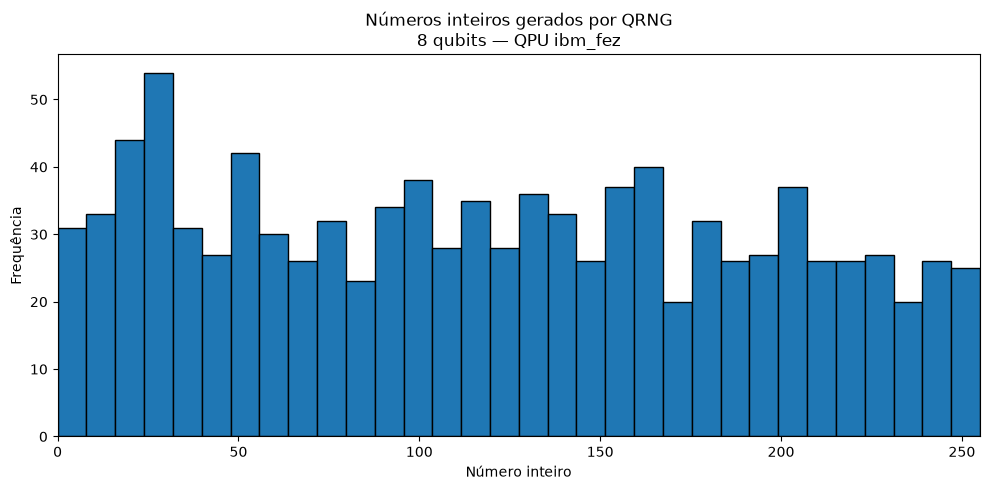

In [ ]:
from google.colab import userdata

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

import matplotlib.pyplot as plt


# 1. Conexão com a IBM Quantum

token_ibm = userdata.get("IBM_QUANTUM_TOKEN")
crn_ibm = userdata.get("IBM_QUANTUM_CRN")

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token_ibm,
    instance=crn_ibm
)

print("Conectado à IBM Quantum!")


# 2. Configurações

numero_qubits = 8
quantidade_numeros = 1000

valor_minimo = 0
valor_maximo = (2 ** numero_qubits) - 1

print(f"Intervalo possível: {valor_minimo} até {valor_maximo}")


# 3. Escolha da QPU

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=numero_qubits
)

print("QPU escolhida:", backend.name)


# 4. Circuito QRNG

circuito = QuantumCircuit(numero_qubits, numero_qubits)

for qubit in range(numero_qubits):
    circuito.h(qubit)

for qubit in range(numero_qubits):
    circuito.measure(qubit, qubit)


# 5. Transpilação

pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

circuito_isa = pass_manager.run(circuito)


# 6. Execução na QPU real

sampler = SamplerV2(mode=backend)

job = sampler.run(
    [circuito_isa],
    shots=quantidade_numeros
)

print("ID do trabalho:", job.job_id())
print("Circuito enviado para a QPU.")


# 7. Resultados binários

resultado = job.result()

sequencias_medidas = resultado[0].data.c.get_bitstrings()


# 8. Conversão de binário para inteiro

numeros_inteiros = []

for sequencia in sequencias_medidas:
    numero = int(sequencia, 2)
    numeros_inteiros.append(numero)


print("\nPrimeiras 10 sequências binárias:")
print(sequencias_medidas[:10])

print("\nPrimeiros 10 números inteiros:")
print(numeros_inteiros[:10])

print("\nQuantidade de números gerados:", len(numeros_inteiros))


# 9. Histograma dos números gerados

plt.figure(figsize=(10, 5))

plt.hist(
    numeros_inteiros,
    bins=32,
    edgecolor="black"
)

plt.title(
    f"Números inteiros gerados por QRNG\n"
    f"{numero_qubits} qubits — QPU {backend.name}"
)

plt.xlabel("Número inteiro")
plt.ylabel("Frequência")

plt.xlim(valor_minimo, valor_maximo)

plt.tight_layout()
plt.show()

qiskit_runtime_service._discover_account:WARNING:2026-07-23 20:03:37,322: Loading account with the given token. A saved account will not be used.


Conectado à IBM Quantum!
Serão gerados 10000 números.
Intervalo possível: 0 até 255
QPU escolhida: ibm_fez
ID do trabalho: d9h7784honhs73aclqm0
O circuito foi enviado para a fila da QPU.

Primeiras 10 sequências binárias:
['01110010', '11111100', '00110100', '11101000', '10110111', '10011100', '00000111', '00000100', '01111101', '01100111']

Primeiros 10 números inteiros:
[114, 252, 52, 232, 183, 156, 7, 4, 125, 103]

Quantidade de números gerados: 10000
Menor número gerado: 0
Maior número gerado: 255


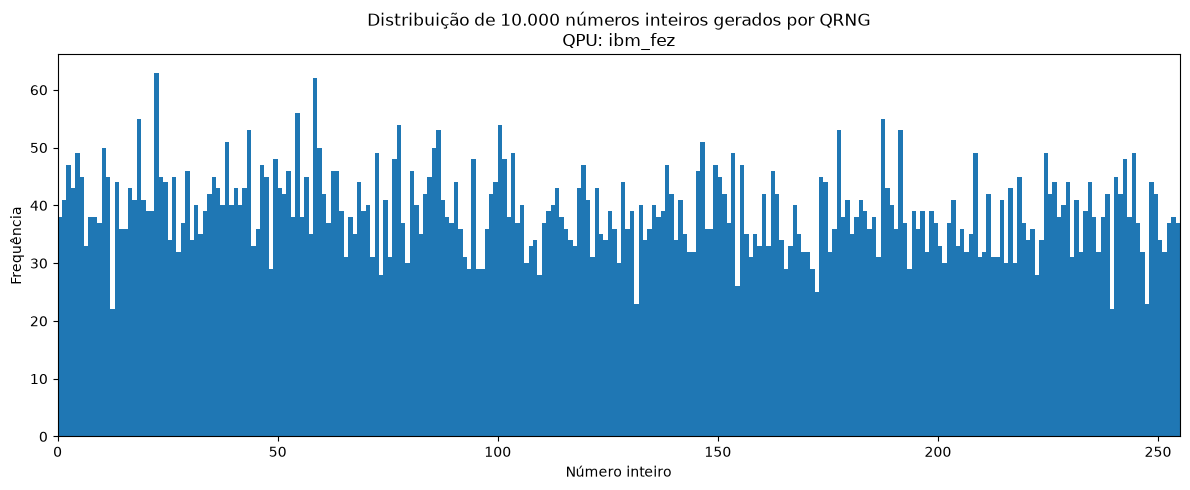

In [ ]:
from google.colab import userdata

from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

import matplotlib.pyplot as plt


# 1. Conexão com a IBM Quantum

token_ibm = userdata.get("IBM_QUANTUM_TOKEN")
crn_ibm = userdata.get("IBM_QUANTUM_CRN")

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token_ibm,
    instance=crn_ibm
)

print("Conectado à IBM Quantum!")


# 2. Configurações

numero_qubits = 8
quantidade_numeros = 10_000

valor_minimo = 0
valor_maximo = (2 ** numero_qubits) - 1

print(f"Serão gerados {quantidade_numeros} números.")
print(f"Intervalo possível: {valor_minimo} até {valor_maximo}")



# 3. Escolha de uma QPU real

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=numero_qubits
)

print("QPU escolhida:", backend.name)


# 4. Construção do circuito QRNG

circuito = QuantumCircuit(numero_qubits, numero_qubits)

# Aplica a porta Hadamard em todos os qubits
for qubit in range(numero_qubits):
    circuito.h(qubit)

# Mede cada qubit
for qubit in range(numero_qubits):
    circuito.measure(qubit, qubit)


# 5. Transpilação para a QPU

pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

circuito_isa = pass_manager.run(circuito)


# 6. Execução na QPU real

sampler = SamplerV2(mode=backend)

job = sampler.run(
    [circuito_isa],
    shots=quantidade_numeros
)

print("ID do trabalho:", job.job_id())
print("O circuito foi enviado para a fila da QPU.")


# 7. Obtenção dos resultados

resultado = job.result()

dados = resultado[0].data

sequencias_binarias = dados.c.get_bitstrings()


# 8. Conversão para números inteiros

numeros_inteiros = []

for sequencia in sequencias_binarias:
    numero_decimal = int(sequencia, 2)
    numeros_inteiros.append(numero_decimal)


# 9. Conferência dos resultados

print("\nPrimeiras 10 sequências binárias:")
print(sequencias_binarias[:10])

print("\nPrimeiros 10 números inteiros:")
print(numeros_inteiros[:10])

print("\nQuantidade de números gerados:", len(numeros_inteiros))

print("Menor número gerado:", min(numeros_inteiros))
print("Maior número gerado:", max(numeros_inteiros))


# 10. Histograma


plt.figure(figsize=(12, 5))

plt.hist(
    numeros_inteiros,
    bins=256,
    range=(0, 256)
)

plt.title(
    f"Distribuição de 10.000 números inteiros gerados por QRNG\n"
    f"QPU: {backend.name}"
)

plt.xlabel("Número inteiro")
plt.ylabel("Frequência")

plt.xlim(0, 255)

plt.tight_layout()
plt.show()

qiskit_runtime_service._discover_account:WARNING:2026-07-24 18:36:59,288: Loading account with the given token. A saved account will not be used.


Conectado à IBM Quantum!

Configurações:
Número de qubits: 8
Quantidade de execuções: 10000
Quantidade bruta esperada de bits: 80000

QPU escolhida: ibm_marrakesh

ID do trabalho: d9hr1krsbqfc73eqh0qg
O circuito foi enviado para a fila da QPU.
Aguardando o resultado...

Quantidade de execuções recebidas: 10000

Primeiras 10 medições:
['11101011', '00110011', '00001001', '10111111', '00100011', '10111100', '11000011', '00001101', '10000100', '00010111']

Quantidade de bits brutos: 80000

Primeiros 100 bits brutos:
1110101100110011000010011011111100100011101111001100001100001101100001000001011111000111101110010111

Quantidade de bits após Von Neumann: 20039

Primeiros 100 bits extraídos:
1110111010000110001100000110011100100001010101111011011110110100101110010010100101110011110100001111

Extração:
Bits brutos: 80000
Bits extraídos: 20039
Bits descartados: 59961
Taxa de aproveitamento: 25.05%

Sequência bruta:
P(0): 49.4612%
P(1): 50.5388%

Após o extrator de Von Neumann:
P(0): 49.3438%
P

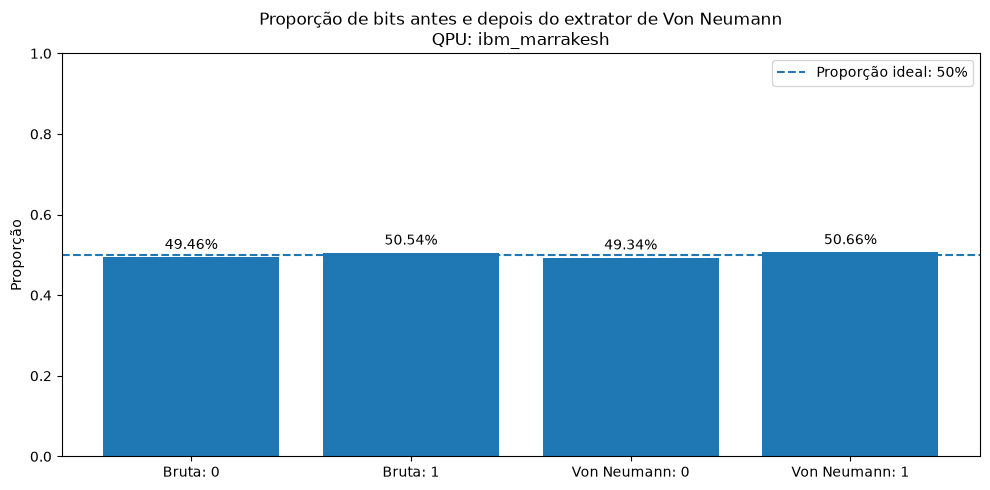

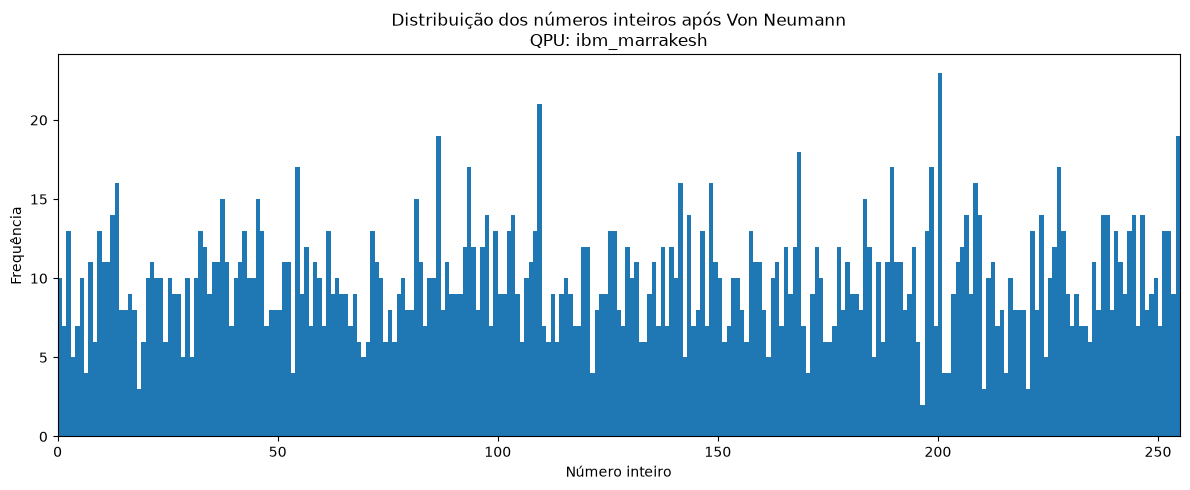

In [ ]:
from google.colab import userdata

from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

import matplotlib.pyplot as plt


# FUNÇÕES

def extrator_von_neumann(bits_brutos):
    """
    Aplica o extrator de Von Neumann.

    Regras:
        01 -> 0
        10 -> 1
        00 -> descartado
        11 -> descartado
    """

    bits_extraidos = []

    # Percorre a sequência em pares
    for indice in range(0, len(bits_brutos) - 1, 2):

        primeiro_bit = bits_brutos[indice]
        segundo_bit = bits_brutos[indice + 1]

        if primeiro_bit == "0" and segundo_bit == "1":
            bits_extraidos.append("0")

        elif primeiro_bit == "1" and segundo_bit == "0":
            bits_extraidos.append("1")

        # Os pares 00 e 11 não produzem saída

    return "".join(bits_extraidos)


def calcular_proporcoes(bits):
    """
    Calcula a proporção de zeros e uns.
    """

    total = len(bits)

    if total == 0:
        return 0, 0

    quantidade_zeros = bits.count("0")
    quantidade_uns = bits.count("1")

    proporcao_zero = quantidade_zeros / total
    proporcao_um = quantidade_uns / total

    return proporcao_zero, proporcao_um


def converter_bits_para_inteiros(bits, tamanho_bloco=8):
    """
    Divide uma sequência de bits em blocos e converte
    cada bloco binário para um número inteiro.
    """

    numeros = []

    # O "- tamanho_bloco + 1" impede blocos incompletos
    limite = len(bits) - tamanho_bloco + 1

    for indice in range(0, limite, tamanho_bloco):

        bloco = bits[indice:indice + tamanho_bloco]

        numero_decimal = int(bloco, 2)

        numeros.append(numero_decimal)

    return numeros


# CONEXÃO COM A IBM QUANTUM

token_ibm = userdata.get("IBM_QUANTUM_TOKEN")
crn_ibm = userdata.get("IBM_QUANTUM_CRN")

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token_ibm,
    instance=crn_ibm
)

print("Conectado à IBM Quantum!")


# CONFIGURAÇÕES

numero_qubits = 8

# Cada execução produz 8 bits
quantidade_execucoes = 10_000

quantidade_bits_esperada = (
    numero_qubits * quantidade_execucoes
)

print("\nConfigurações:")
print("Número de qubits:", numero_qubits)
print("Quantidade de execuções:", quantidade_execucoes)
print("Quantidade bruta esperada de bits:", quantidade_bits_esperada)


# ESCOLHA DA QPU REAL

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=numero_qubits
)

print("\nQPU escolhida:", backend.name)


# CONSTRUÇÃO DO CIRCUITO QRNG

circuito = QuantumCircuit(
    numero_qubits,
    numero_qubits
)

# Aplica Hadamard em todos os qubits
for qubit in range(numero_qubits):
    circuito.h(qubit)

# Mede todos os qubits
for qubit in range(numero_qubits):
    circuito.measure(qubit, qubit)


# TRANSPILAÇÃO PARA A QPU

pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

circuito_isa = pass_manager.run(circuito)


# EXECUÇÃO NA QPU REAL

sampler = SamplerV2(mode=backend)

job = sampler.run(
    [circuito_isa],
    shots=quantidade_execucoes
)

print("\nID do trabalho:", job.job_id())
print("O circuito foi enviado para a fila da QPU.")
print("Aguardando o resultado...")


# RECUPERAÇÃO DAS MEDIÇÕES

resultado = job.result()

dados = resultado[0].data

sequencias_binarias = dados.c.get_bitstrings()

print("\nQuantidade de execuções recebidas:", len(sequencias_binarias))

print("\nPrimeiras 10 medições:")
print(sequencias_binarias[:10])


# CRIAÇÃO DA SEQUÊNCIA BRUTA

# Junta as sequências de 8 bits
bits_brutos = "".join(sequencias_binarias)

print("\nQuantidade de bits brutos:", len(bits_brutos))

print("\nPrimeiros 100 bits brutos:")
print(bits_brutos[:100])


# EXTRATOR DE VON NEUMANN

bits_extraidos = extrator_von_neumann(bits_brutos)

print("\nQuantidade de bits após Von Neumann:", len(bits_extraidos))

print("\nPrimeiros 100 bits extraídos:")
print(bits_extraidos[:100])


# TAXA DE APROVEITAMENTO

quantidade_descartada = (
    len(bits_brutos) - len(bits_extraidos)
)

taxa_aproveitamento = (
    len(bits_extraidos) / len(bits_brutos)
)

print("\nExtração:")
print("Bits brutos:", len(bits_brutos))
print("Bits extraídos:", len(bits_extraidos))
print("Bits descartados:", quantidade_descartada)
print(f"Taxa de aproveitamento: {taxa_aproveitamento:.2%}")


# PROPORÇÕES ANTES E DEPOIS

proporcao_zero_bruta, proporcao_um_bruta = calcular_proporcoes(
    bits_brutos
)

proporcao_zero_extraida, proporcao_um_extraida = calcular_proporcoes(
    bits_extraidos
)

print("\nSequência bruta:")
print(f"P(0): {proporcao_zero_bruta:.4%}")
print(f"P(1): {proporcao_um_bruta:.4%}")

print("\nApós o extrator de Von Neumann:")
print(f"P(0): {proporcao_zero_extraida:.4%}")
print(f"P(1): {proporcao_um_extraida:.4%}")


# CONVERSÃO PARA NÚMEROS INTEIROS

numeros_brutos = converter_bits_para_inteiros(
    bits_brutos,
    tamanho_bloco=8
)

numeros_extraidos = converter_bits_para_inteiros(
    bits_extraidos,
    tamanho_bloco=8
)

print("\nPrimeiros 20 números brutos:")
print(numeros_brutos[:20])

print("\nPrimeiros 20 números após Von Neumann:")
print(numeros_extraidos[:20])

print("\nQuantidade de números brutos:", len(numeros_brutos))
print("Quantidade de números após Von Neumann:", len(numeros_extraidos))


# GRÁFICO DAS PROPORÇÕES

categorias = [
    "Bruta: 0",
    "Bruta: 1",
    "Von Neumann: 0",
    "Von Neumann: 1"
]

proporcoes = [
    proporcao_zero_bruta,
    proporcao_um_bruta,
    proporcao_zero_extraida,
    proporcao_um_extraida
]

plt.figure(figsize=(10, 5))

barras = plt.bar(
    categorias,
    proporcoes
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Proporção ideal: 50%"
)

plt.title(
    "Proporção de bits antes e depois do extrator de Von Neumann\n"
    f"QPU: {backend.name}"
)

plt.ylabel("Proporção")
plt.ylim(0, 1)

for barra, proporcao in zip(barras, proporcoes):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        proporcao + 0.02,
        f"{proporcao:.2%}",
        ha="center"
    )

plt.legend()
plt.tight_layout()
plt.show()


#HISTOGRAMA DOS INTEIROS EXTRAÍDOS

if len(numeros_extraidos) > 0:

    plt.figure(figsize=(12, 5))

    plt.hist(
        numeros_extraidos,
        bins=256,
        range=(0, 256)
    )

    plt.title(
        "Distribuição dos números inteiros após Von Neumann\n"
        f"QPU: {backend.name}"
    )

    plt.xlabel("Número inteiro")
    plt.ylabel("Frequência")
    plt.xlim(0, 255)

    plt.tight_layout()
    plt.show()

else:
    print(
        "\nNão foram produzidos bits suficientes "
        "para formar números inteiros."
    )

qiskit_runtime_service._discover_account:WARNING:2026-08-06 19:40:41,941: Loading account with the given token. A saved account will not be used.


Conectado à IBM Quantum!

Configurações:
Número de qubits: 8
Quantidade de execuções: 10000
Quantidade esperada de bits: 80000

QPU escolhida: ibm_marrakesh

ID do trabalho: d9qe6gftfhrs73dq68a0
O circuito foi enviado para a fila da QPU.
Aguardando o resultado...

Quantidade de medições recebidas:
10000

Primeiras 10 medições:
['11110010', '10001010', '00000100', '01001110', '01101011', '00011011', '00110001', '00000011', '10000110', '11001001']

Quantidade de bits brutos:
80000

Primeiros 100 bits:
1111001010001010000001000100111001101011000110110011000100000011100001101100100101001100100111001101

Primeiros 500 caracteres gerados:
Y#'isn1`KfBwKLX{:VLS[qDhL-ucwh6Iy9jtL{iQ|bEI%?efLv@RlKGrSN6r_j{1H^-VxlINAU<Z\aOFa-@XGO3KN.~yYtY~2+cECg9:Vv=;bNbAGCEv*xR=;!C=Ae2w>|4D4!<HYiURwA=:?dqMDc$no"gHb%?}]{)9DAjFZ(fv7l_JYW!I>><N%/zfc\{4KsXlz-dO:0?4(.%pFe*'uQ+/E)I9!W04S+d)Nml]{wdJ6B**@XM~O?f(UyT`r3rr+xXfM-$Cni|HB?iuPI6(@L9,qjyZq%(+~dM-)([r;(.WE2v)'t\"^=X*dB?ipBCFcGUGCQ\:Z"jo'X_e2qR!#4*xwQ+o*jsza(FJ/^,

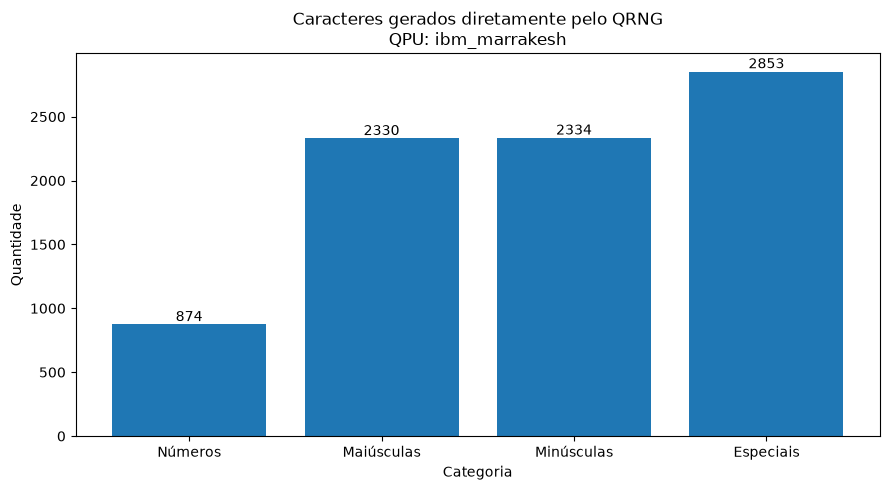

In [ ]:
from google.colab import userdata

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

import string
import matplotlib.pyplot as plt

# FUNÇÃO DE CONVERSÃO

def converter_bits_para_caracteres(bits):
    """
    Converte bits em:

    - números;
    - letras maiúsculas;
    - letras minúsculas;
    - caracteres especiais.

    São utilizados blocos de 7 bits, que representam valores
    de 0 a 127.

    Como existem 94 caracteres disponíveis, valores de 94 a 127
    são descartados para evitar viés.
    """

    caracteres = (
        string.digits
        + string.ascii_uppercase
        + string.ascii_lowercase
        + string.punctuation
    )

    resultado = []
    blocos_descartados = 0

    tamanho_bloco = 7

    for indice in range(0, len(bits) - tamanho_bloco + 1, tamanho_bloco):

        bloco = bits[indice:indice + tamanho_bloco]

        valor_decimal = int(bloco, 2)

        if valor_decimal < len(caracteres):
            resultado.append(caracteres[valor_decimal])
        else:
            blocos_descartados += 1

    return "".join(resultado), blocos_descartados


# CONEXÃO COM A IBM QUANTUM

token_ibm = userdata.get("IBM_QUANTUM_TOKEN")
crn_ibm = userdata.get("IBM_QUANTUM_CRN")

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token_ibm,
    instance=crn_ibm
)

print("Conectado à IBM Quantum!")


# CONFIGURAÇÕES

numero_qubits = 8
quantidade_execucoes = 10_000

quantidade_bits_esperada = numero_qubits * quantidade_execucoes

print("\nConfigurações:")
print("Número de qubits:", numero_qubits)
print("Quantidade de execuções:", quantidade_execucoes)
print("Quantidade esperada de bits:", quantidade_bits_esperada)


# ESCOLHA DE UMA QPU REAL

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=numero_qubits
)

print("\nQPU escolhida:", backend.name)


# CONSTRUÇÃO DO CIRCUITO QRNG

circuito = QuantumCircuit(numero_qubits, numero_qubits)

# Aplica Hadamard em todos os qubits
for qubit in range(numero_qubits):
    circuito.h(qubit)

# Mede todos os qubits
for qubit in range(numero_qubits):
    circuito.measure(qubit, qubit)

# TRANSPILAÇÃO PARA A QPU

pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

circuito_isa = pass_manager.run(circuito)

# EXECUÇÃO NA QPU REAL

sampler = SamplerV2(mode=backend)

job = sampler.run(
    [circuito_isa],
    shots=quantidade_execucoes
)

print("\nID do trabalho:", job.job_id())
print("O circuito foi enviado para a fila da QPU.")
print("Aguardando o resultado...")


# RECUPERAÇÃO DAS MEDIÇÕES

resultado = job.result()

dados = resultado[0].data

sequencias_binarias = dados.c.get_bitstrings()

print("\nQuantidade de medições recebidas:")
print(len(sequencias_binarias))

print("\nPrimeiras 10 medições:")
print(sequencias_binarias[:10])

# CRIAÇÃO DA SEQUÊNCIA BRUTA

bits_brutos = "".join(sequencias_binarias)

print("\nQuantidade de bits brutos:")
print(len(bits_brutos))

print("\nPrimeiros 100 bits:")
print(bits_brutos[:100])

# CONVERSÃO PARA CARACTERES

sequencia_caracteres, blocos_descartados = (
    converter_bits_para_caracteres(bits_brutos)
)

print("\nPrimeiros 500 caracteres gerados:")
print(sequencia_caracteres[:500])

print("\nQuantidade total de caracteres:")
print(len(sequencia_caracteres))

print("Blocos de 7 bits descartados:")
print(blocos_descartados)

# CONTAGEM DAS CATEGORIAS
quantidade_numeros = sum(
    caractere.isdigit()
    for caractere in sequencia_caracteres
)

quantidade_maiusculas = sum(
    caractere.isupper()
    for caractere in sequencia_caracteres
)

quantidade_minusculas = sum(
    caractere.islower()
    for caractere in sequencia_caracteres
)

quantidade_especiais = sum(
    caractere in string.punctuation
    for caractere in sequencia_caracteres
)


print("\nDistribuição por categoria:")
print("Números:", quantidade_numeros)
print("Letras maiúsculas:", quantidade_maiusculas)
print("Letras minúsculas:", quantidade_minusculas)
print("Caracteres especiais:", quantidade_especiais)

# GRÁFICO DAS CATEGORIAS

categorias = [
    "Números",
    "Maiúsculas",
    "Minúsculas",
    "Especiais"
]

quantidades = [
    quantidade_numeros,
    quantidade_maiusculas,
    quantidade_minusculas,
    quantidade_especiais
]

plt.figure(figsize=(9, 5))

barras = plt.bar(
    categorias,
    quantidades
)

plt.title(
    "Caracteres gerados diretamente pelo QRNG\n"
    f"QPU: {backend.name}"
)

plt.xlabel("Categoria")
plt.ylabel("Quantidade")

for barra, quantidade in zip(barras, quantidades):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        quantidade,
        str(quantidade),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

qiskit_runtime_service._discover_account:WARNING:2026-08-06 19:41:51,922: Loading account with the given token. A saved account will not be used.


Conectado à IBM Quantum!

Configurações:
Número de qubits: 8
Quantidade de execuções: 10000
Quantidade esperada de bits brutos: 80000

QPU escolhida: ibm_marrakesh

ID do trabalho: d9qe718pdb6s73e3ejt0
O circuito foi enviado para a QPU.
Aguardando o resultado...

Quantidade de bits brutos:
80000

Primeiros 100 bits brutos:
1110100000101000010100011000011110011110110001000000100110100000011111100111101100110000111110100110

Extração SHA-256:
Tamanho de cada bloco de entrada: 1024
Quantidade de blocos processados: 78
Bits produzidos por bloco: 256
Quantidade total de bits extraídos: 19968

Primeiros 5 hashes SHA-256:
Hash 1: f8c85c6dac0591edade57843a07101f954ffb0ec07b47bc03fbac4c19defca1c
Hash 2: cc3956106235348b0f3d52b1abc929d7e57db7eab4807d058f422c8dab6f0c89
Hash 3: 07dfbbd7648b1b0a04fc7b08ae7d4b30196b1e2212fbcdf4ba456cb3f18e52cc
Hash 4: 85805bbf056df0d1bc3d285a7d949f811f14e8f06ed460e32893fc24b2cfb5b8
Hash 5: 7059169c9c68fb1bdf7ead4b97e5cf4ede74f156ae90e32e3286cc8222c39d5a

Primeiros 2

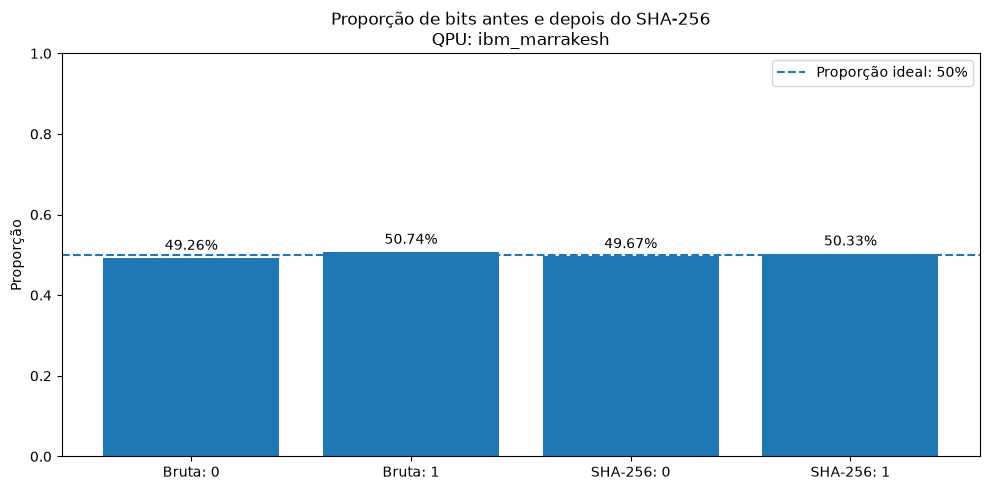

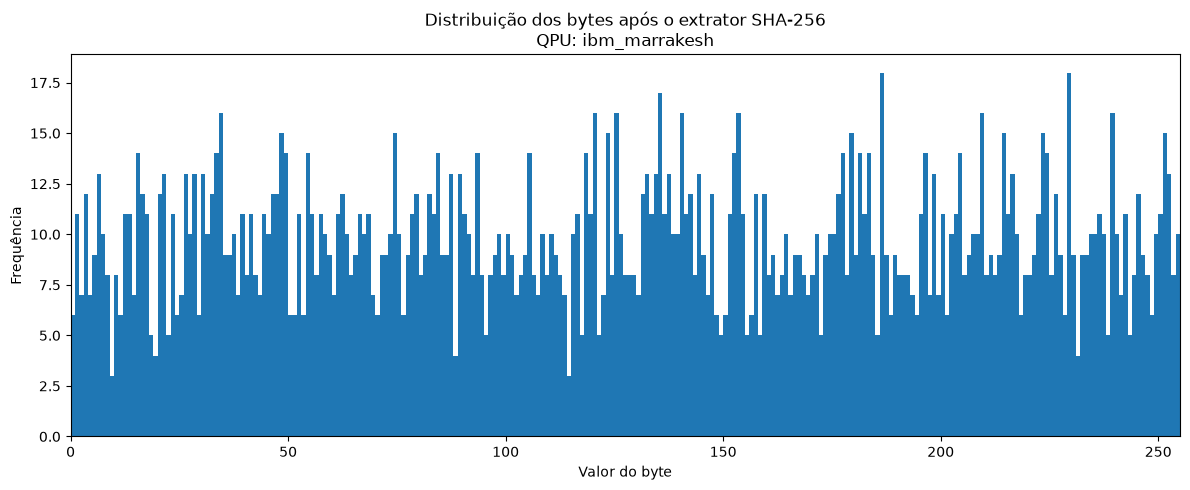

In [ ]:
from google.colab import userdata

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

import hashlib
import matplotlib.pyplot as plt


# 1. FUNÇÕES

def bits_para_bytes(bits):
    """
    Converte uma string de bits em bytes.

    A quantidade de bits deve ser múltipla de 8.
    """

    if len(bits) % 8 != 0:
        raise ValueError(
            "A quantidade de bits deve ser múltipla de 8."
        )

    numero = int(bits, 2)

    quantidade_bytes = len(bits) // 8

    return numero.to_bytes(
        quantidade_bytes,
        byteorder="big"
    )


def extrator_sha256(bits_brutos, tamanho_bloco=1024):
    """
    Divide a sequência bruta em blocos e aplica SHA-256
    separadamente em cada bloco.

    Cada bloco gera 256 bits de saída.
    """

    if tamanho_bloco <= 0:
        raise ValueError(
            "O tamanho do bloco deve ser maior que zero."
        )

    if tamanho_bloco % 8 != 0:
        raise ValueError(
            "O tamanho do bloco deve ser múltiplo de 8."
        )

    bits_extraidos = []
    hashes_hexadecimais = []

    quantidade_blocos = len(bits_brutos) // tamanho_bloco

    for indice in range(quantidade_blocos):

        inicio = indice * tamanho_bloco
        fim = inicio + tamanho_bloco

        bloco_bits = bits_brutos[inicio:fim]

        bloco_bytes = bits_para_bytes(bloco_bits)

        hash_bytes = hashlib.sha256(bloco_bytes).digest()

        hash_hexadecimal = hash_bytes.hex()

        hash_bits = "".join(
            format(byte, "08b")
            for byte in hash_bytes
        )

        bits_extraidos.append(hash_bits)
        hashes_hexadecimais.append(hash_hexadecimal)

    return (
        "".join(bits_extraidos),
        hashes_hexadecimais,
        quantidade_blocos
    )


def calcular_proporcoes(bits):
    """
    Calcula a proporção de zeros e uns.
    """

    total = len(bits)

    if total == 0:
        return 0, 0

    proporcao_zero = bits.count("0") / total
    proporcao_um = bits.count("1") / total

    return proporcao_zero, proporcao_um


def converter_bits_para_inteiros(bits, tamanho_bloco=8):
    """
    Converte blocos de bits em números inteiros.
    """

    numeros = []

    quantidade_blocos = len(bits) // tamanho_bloco

    for indice in range(quantidade_blocos):

        inicio = indice * tamanho_bloco
        fim = inicio + tamanho_bloco

        bloco = bits[inicio:fim]

        numeros.append(int(bloco, 2))

    return numeros


# 2. CONEXÃO COM A IBM QUANTUM

token_ibm = userdata.get("IBM_QUANTUM_TOKEN")
crn_ibm = userdata.get("IBM_QUANTUM_CRN")

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token_ibm,
    instance=crn_ibm
)

print("Conectado à IBM Quantum!")


# 3. CONFIGURAÇÕES

numero_qubits = 8
quantidade_execucoes = 10_000

# Cada bloco de 1024 bits produzirá 256 bits
tamanho_bloco_sha = 1024

print("\nConfigurações:")
print("Número de qubits:", numero_qubits)
print("Quantidade de execuções:", quantidade_execucoes)
print(
    "Quantidade esperada de bits brutos:",
    numero_qubits * quantidade_execucoes
)


# 4. ESCOLHA DA QPU REAL

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=numero_qubits
)

print("\nQPU escolhida:", backend.name)


# 5. CONSTRUÇÃO DO CIRCUITO QRNG

circuito = QuantumCircuit(
    numero_qubits,
    numero_qubits
)

for qubit in range(numero_qubits):
    circuito.h(qubit)

for qubit in range(numero_qubits):
    circuito.measure(qubit, qubit)


# 6. TRANSPILAÇÃO PARA A QPU

pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

circuito_isa = pass_manager.run(circuito)


# 7. EXECUÇÃO NA QPU REAL

sampler = SamplerV2(mode=backend)

job = sampler.run(
    [circuito_isa],
    shots=quantidade_execucoes
)

print("\nID do trabalho:", job.job_id())
print("O circuito foi enviado para a QPU.")
print("Aguardando o resultado...")


# 8. RECUPERAÇÃO DOS RESULTADOS

resultado = job.result()

dados = resultado[0].data

sequencias_binarias = dados.c.get_bitstrings()

bits_brutos = "".join(sequencias_binarias)

print("\nQuantidade de bits brutos:")
print(len(bits_brutos))

print("\nPrimeiros 100 bits brutos:")
print(bits_brutos[:100])


# 9. APLICAÇÃO DO SHA-256

(
    bits_sha256,
    hashes_hexadecimais,
    quantidade_blocos_sha
) = extrator_sha256(
    bits_brutos,
    tamanho_bloco=tamanho_bloco_sha
)


print("\nExtração SHA-256:")
print("Tamanho de cada bloco de entrada:", tamanho_bloco_sha)
print("Quantidade de blocos processados:", quantidade_blocos_sha)
print("Bits produzidos por bloco:", 256)
print("Quantidade total de bits extraídos:", len(bits_sha256))


# 10. EXEMPLOS DOS HASHES

print("\nPrimeiros 5 hashes SHA-256:")

for indice, hash_hexadecimal in enumerate(
    hashes_hexadecimais[:5],
    start=1
):
    print(f"Hash {indice}: {hash_hexadecimal}")


print("\nPrimeiros 256 bits extraídos:")
print(bits_sha256[:256])


# 11. BITS NÃO UTILIZADOS

bits_utilizados = quantidade_blocos_sha * tamanho_bloco_sha

bits_nao_utilizados = len(bits_brutos) - bits_utilizados

print("\nBits brutos utilizados:", bits_utilizados)
print("Bits restantes não utilizados:", bits_nao_utilizados)


# 12. PROPORÇÃO ANTES E DEPOIS

proporcao_zero_bruta, proporcao_um_bruta = calcular_proporcoes(
    bits_brutos
)

proporcao_zero_sha, proporcao_um_sha = calcular_proporcoes(
    bits_sha256
)


print("\nSequência bruta:")
print(f"P(0): {proporcao_zero_bruta:.4%}")
print(f"P(1): {proporcao_um_bruta:.4%}")

print("\nApós SHA-256:")
print(f"P(0): {proporcao_zero_sha:.4%}")
print(f"P(1): {proporcao_um_sha:.4%}")


# 13. CONVERSÃO PARA INTEIROS

numeros_sha256 = converter_bits_para_inteiros(
    bits_sha256,
    tamanho_bloco=8
)

print("\nPrimeiros 20 números após SHA-256:")
print(numeros_sha256[:20])

print(
    "Quantidade de números inteiros após SHA-256:",
    len(numeros_sha256)
)


# 14. GRÁFICO DE PROPORÇÕES

categorias = [
    "Bruta: 0",
    "Bruta: 1",
    "SHA-256: 0",
    "SHA-256: 1"
]

proporcoes = [
    proporcao_zero_bruta,
    proporcao_um_bruta,
    proporcao_zero_sha,
    proporcao_um_sha
]

plt.figure(figsize=(10, 5))

barras = plt.bar(
    categorias,
    proporcoes
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Proporção ideal: 50%"
)

plt.title(
    "Proporção de bits antes e depois do SHA-256\n"
    f"QPU: {backend.name}"
)

plt.ylabel("Proporção")
plt.ylim(0, 1)

for barra, proporcao in zip(barras, proporcoes):

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        proporcao + 0.02,
        f"{proporcao:.2%}",
        ha="center"
    )

plt.legend()
plt.tight_layout()
plt.show()


# 15. HISTOGRAMA DOS BYTES EXTRAÍDOS

plt.figure(figsize=(12, 5))

plt.hist(
    numeros_sha256,
    bins=256,
    range=(0, 256)
)

plt.title(
    "Distribuição dos bytes após o extrator SHA-256\n"
    f"QPU: {backend.name}"
)

plt.xlabel("Valor do byte")
plt.ylabel("Frequência")
plt.xlim(0, 255)

plt.tight_layout()
plt.show()

qiskit_runtime_service._discover_account:WARNING:2026-08-06 20:01:32,608: Loading account with the given token. A saved account will not be used.


Conectado à IBM Quantum!
QPU escolhida: ibm_marrakesh
ID do trabalho: d9qeg8npemts73cr5kug
Circuito enviado para a QPU IBM.
Aguardando o resultado...

Quantidade de medições: 1000
Primeiras 20 medições:
['00', '11', '00', '11', '00', '11', '00', '00', '00', '11', '00', '00', '11', '11', '00', '11', '00', '00', '00', '11']

Resultados:
00: 510 ocorrências — 51.00%
01: 2 ocorrências — 0.20%
10: 17 ocorrências — 1.70%
11: 471 ocorrências — 47.10%

Taxa de resultados correlacionados (00 ou 11): 98.10%

Bits aleatórios válidos:
0101010001001101000100110001111011101101011101101001010111001111100101101100110100000110001000010001
Quantidade de bits gerados: 981
Resultados descartados: 19

P(0): 51.99%
P(1): 48.01%


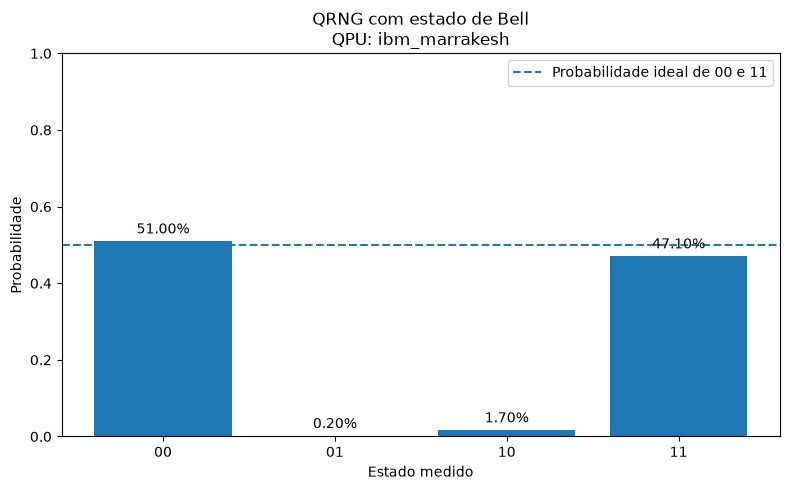

In [ ]:
#hammadan com cnot em seguida

from google.colab import userdata

from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

import matplotlib.pyplot as plt


# 1. CONEXÃO COM A IBM QUANTUM

token_ibm = userdata.get("IBM_QUANTUM_TOKEN")
crn_ibm = userdata.get("IBM_QUANTUM_CRN")

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token_ibm,
    instance=crn_ibm
)

print("Conectado à IBM Quantum!")


# 2. CONFIGURAÇÕES

quantidade_execucoes = 1000


# 3. ESCOLHA DE UMA QPU REAL

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=2
)

print("QPU escolhida:", backend.name)


# 4. CONSTRUÇÃO DO ESTADO DE BELL

circuito = QuantumCircuit(2, 2)

# Coloca o qubit 0 em superposição
circuito.h(0)

# Emaranha o qubit 1 com o qubit 0
circuito.cx(0, 1)

# Mede os dois qubits
circuito.measure([0, 1], [0, 1])


# 5. TRANSPILAÇÃO PARA A QPU

pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

circuito_isa = pass_manager.run(circuito)


# 6. EXECUÇÃO NA QPU REAL

sampler = SamplerV2(mode=backend)

job = sampler.run(
    [circuito_isa],
    shots=quantidade_execucoes
)

print("ID do trabalho:", job.job_id())
print("Circuito enviado para a QPU IBM.")
print("Aguardando o resultado...")


# 7. RECUPERAÇÃO DAS MEDIÇÕES

resultado = job.result()

sequencias = resultado[0].data.c.get_bitstrings()

print("\nQuantidade de medições:", len(sequencias))
print("Primeiras 20 medições:")
print(sequencias[:20])


# 8. CONTAGEM DOS RESULTADOS

resultados_possiveis = ["00", "01", "10", "11"]

contagens = {
    resultado: sequencias.count(resultado)
    for resultado in resultados_possiveis
}

probabilidades = {
    resultado: contagens[resultado] / len(sequencias)
    for resultado in resultados_possiveis
}


print("\nResultados:")

for resultado in resultados_possiveis:
    print(
        f"{resultado}: "
        f"{contagens[resultado]} ocorrências — "
        f"{probabilidades[resultado]:.2%}"
    )


# 9. TAXA DE CORRELAÇÃO

resultados_correlacionados = (
    contagens["00"] + contagens["11"]
)

taxa_correlacao = (
    resultados_correlacionados / len(sequencias)
)

print(
    "\nTaxa de resultados correlacionados "
    f"(00 ou 11): {taxa_correlacao:.2%}"
)


# 10. GERAÇÃO DE BITS ALEATÓRIOS

# Como 00 e 11 representam o mesmo bit nos dois qubits,
# usamos apenas um bit de cada medição válida.

bits_aleatorios = []

resultados_descartados = 0

for sequencia in sequencias:

    if sequencia == "00":
        bits_aleatorios.append("0")

    elif sequencia == "11":
        bits_aleatorios.append("1")

    else:
        # 01 e 10 indicam perda de correlação ou erro
        resultados_descartados += 1


bits_aleatorios = "".join(bits_aleatorios)

print("\nBits aleatórios válidos:")
print(bits_aleatorios[:100])

print("Quantidade de bits gerados:", len(bits_aleatorios))
print("Resultados descartados:", resultados_descartados)


# 11. PROPORÇÃO DOS BITS GERADOS

if len(bits_aleatorios) > 0:

    quantidade_zeros = bits_aleatorios.count("0")
    quantidade_uns = bits_aleatorios.count("1")

    probabilidade_zero = (
        quantidade_zeros / len(bits_aleatorios)
    )

    probabilidade_um = (
        quantidade_uns / len(bits_aleatorios)
    )

    print(f"\nP(0): {probabilidade_zero:.2%}")
    print(f"P(1): {probabilidade_um:.2%}")


# 12. GRÁFICO DOS ESTADOS MEDIDOS

valores_grafico = [
    probabilidades["00"],
    probabilidades["01"],
    probabilidades["10"],
    probabilidades["11"]
]

plt.figure(figsize=(8, 5))

barras = plt.bar(
    resultados_possiveis,
    valores_grafico
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Probabilidade ideal de 00 e 11"
)

plt.title(
    "QRNG com estado de Bell\n"
    f"QPU: {backend.name}"
)

plt.xlabel("Estado medido")
plt.ylabel("Probabilidade")
plt.ylim(0, 1)

for barra, probabilidade in zip(
    barras,
    valores_grafico
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        probabilidade + 0.02,
        f"{probabilidade:.2%}",
        ha="center"
    )

plt.legend()
plt.tight_layout()
plt.show()

qiskit_runtime_service._discover_account:WARNING:2026-08-06 20:35:04,968: Loading account with the given token. A saved account will not be used.


Conectado à IBM Quantum!
QPU escolhida: ibm_kingston
ID do trabalho: d9qevvntfhrs73dq79sg
Circuito enviado para a QPU IBM.
Aguardando o resultado...

Quantidade de medições recebidas:
1000

Primeiras 20 medições:
['000', '111', '000', '000', '101', '111', '000', '111', '111', '000', '001', '000', '000', '111', '111', '111', '000', '111', '000', '111']

Resultados da QPU:
000: 482 ocorrências — 48.20%
001: 25 ocorrências — 2.50%
010: 1 ocorrências — 0.10%
011: 6 ocorrências — 0.60%
100: 4 ocorrências — 0.40%
101: 19 ocorrências — 1.90%
110: 5 ocorrências — 0.50%
111: 458 ocorrências — 45.80%

Análise do estado GHZ:
Resultados GHZ válidos: 940
Resultados diferentes de 000 ou 111: 60
Taxa de correlação GHZ: 94.00%
Taxa de erro observada: 6.00%

Primeiros 100 bits aleatórios:
0100101100011101010010001010111110000100001011110001110100101011111001100101000100001100011011110001
Quantidade de bits produzidos: 940
Estados descartados: 60

Distribuição dos bits válidos:
Quantidade de zeros: 482


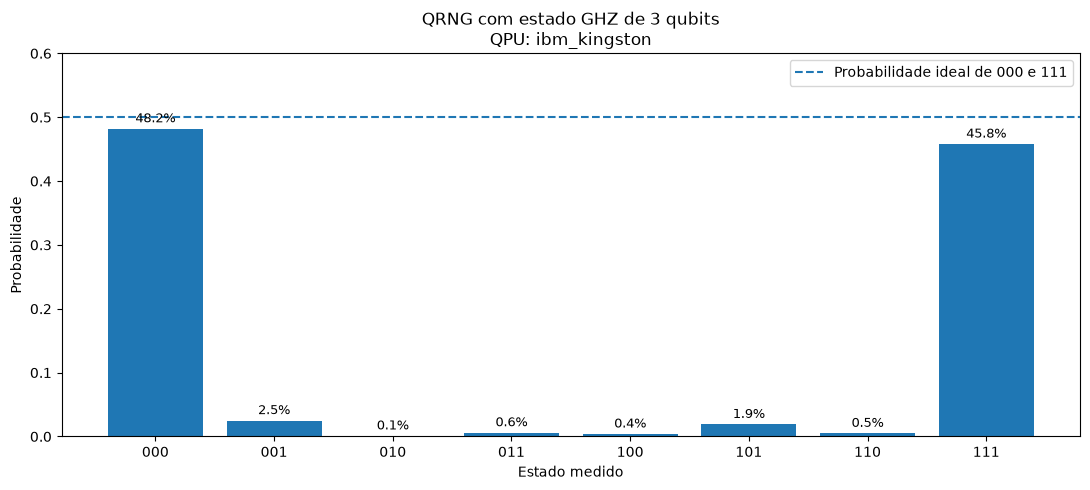

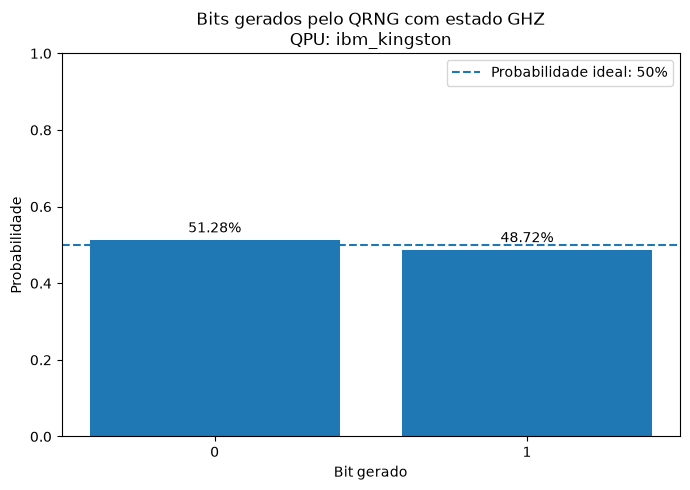

In [ ]:
#QRNG COM ESTADO GHZ

from google.colab import userdata

from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

import matplotlib.pyplot as plt



# 1. CONEXÃO COM A IBM QUANTUM

token_ibm = userdata.get("IBM_QUANTUM_TOKEN")
crn_ibm = userdata.get("IBM_QUANTUM_CRN")

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token_ibm,
    instance=crn_ibm
)

print("Conectado à IBM Quantum!")


# 2. CONFIGURAÇÕES

numero_qubits = 3
quantidade_execucoes = 1000


# 3. ESCOLHA DE UMA QPU REAL

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=numero_qubits
)

print("QPU escolhida:", backend.name)


# 4. CONSTRUÇÃO DO ESTADO GHZ

circuito = QuantumCircuit(
    numero_qubits,
    numero_qubits
)

# Coloca o primeiro qubit em superposição
circuito.h(0)

# Emaranha o qubit 1 com o qubit 0
circuito.cx(0, 1)

# Emaranha o qubit 2 com o qubit 1
circuito.cx(1, 2)

# Mede todos os qubits
circuito.measure(
    range(numero_qubits),
    range(numero_qubits)
)


# 5. TRANSPILAÇÃO PARA A QPU

pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

circuito_isa = pass_manager.run(circuito)


# 6. EXECUÇÃO NA QPU REAL

sampler = SamplerV2(mode=backend)

job = sampler.run(
    [circuito_isa],
    shots=quantidade_execucoes
)

print("ID do trabalho:", job.job_id())
print("Circuito enviado para a QPU IBM.")
print("Aguardando o resultado...")


# 7. RECUPERAÇÃO DAS MEDIÇÕES

resultado = job.result()

dados = resultado[0].data

sequencias_medidas = dados.c.get_bitstrings()

print("\nQuantidade de medições recebidas:")
print(len(sequencias_medidas))

print("\nPrimeiras 20 medições:")
print(sequencias_medidas[:20])


# 8. CONTAGEM DE TODOS OS ESTADOS

estados_possiveis = [
    format(numero, "03b")
    for numero in range(2 ** numero_qubits)
]

contagens = {
    estado: sequencias_medidas.count(estado)
    for estado in estados_possiveis
}

probabilidades = {
    estado: contagens[estado] / len(sequencias_medidas)
    for estado in estados_possiveis
}


print("\nResultados da QPU:")

for estado in estados_possiveis:
    print(
        f"{estado}: "
        f"{contagens[estado]} ocorrências — "
        f"{probabilidades[estado]:.2%}"
    )


# 9. ANÁLISE DA CORRELAÇÃO GHZ

quantidade_000 = contagens["000"]
quantidade_111 = contagens["111"]

resultados_correlacionados = (
    quantidade_000 + quantidade_111
)

taxa_correlacao = (
    resultados_correlacionados
    / len(sequencias_medidas)
)

resultados_com_erro = (
    len(sequencias_medidas)
    - resultados_correlacionados
)

taxa_erro = (
    resultados_com_erro
    / len(sequencias_medidas)
)


print("\nAnálise do estado GHZ:")

print(
    "Resultados GHZ válidos:",
    resultados_correlacionados
)

print(
    "Resultados diferentes de 000 ou 111:",
    resultados_com_erro
)

print(
    f"Taxa de correlação GHZ: {taxa_correlacao:.2%}"
)

print(
    f"Taxa de erro observada: {taxa_erro:.2%}"
)


# 10. CONVERSÃO DOS ESTADOS EM BITS

bits_aleatorios = []

estados_descartados = 0

for sequencia in sequencias_medidas:

    if sequencia == "000":
        bits_aleatorios.append("0")

    elif sequencia == "111":
        bits_aleatorios.append("1")

    else:
        estados_descartados += 1


bits_aleatorios = "".join(bits_aleatorios)


print("\nPrimeiros 100 bits aleatórios:")
print(bits_aleatorios[:100])

print(
    "Quantidade de bits produzidos:",
    len(bits_aleatorios)
)

print(
    "Estados descartados:",
    estados_descartados
)


# 11. PROBABILIDADE DOS BITS GERADOS

if len(bits_aleatorios) > 0:

    quantidade_zeros = bits_aleatorios.count("0")
    quantidade_uns = bits_aleatorios.count("1")

    probabilidade_zero = (
        quantidade_zeros / len(bits_aleatorios)
    )

    probabilidade_um = (
        quantidade_uns / len(bits_aleatorios)
    )

    print("\nDistribuição dos bits válidos:")

    print("Quantidade de zeros:", quantidade_zeros)
    print("Quantidade de uns:", quantidade_uns)

    print(
        f"Probabilidade de 0: {probabilidade_zero:.2%}"
    )

    print(
        f"Probabilidade de 1: {probabilidade_um:.2%}"
    )


# 12. GRÁFICO DOS ESTADOS MEDIDOS

valores_grafico = [
    probabilidades[estado]
    for estado in estados_possiveis
]

plt.figure(figsize=(11, 5))

barras = plt.bar(
    estados_possiveis,
    valores_grafico
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Probabilidade ideal de 000 e 111"
)

plt.title(
    "QRNG com estado GHZ de 3 qubits\n"
    f"QPU: {backend.name}"
)

plt.xlabel("Estado medido")
plt.ylabel("Probabilidade")

plt.ylim(
    0,
    max(0.6, max(valores_grafico) + 0.08)
)

for barra, probabilidade in zip(
    barras,
    valores_grafico
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        probabilidade + 0.01,
        f"{probabilidade:.1%}",
        ha="center",
        fontsize=9
    )

plt.legend()
plt.tight_layout()
plt.show()


# 13. GRÁFICO DOS BITS VÁLIDOS

if len(bits_aleatorios) > 0:

    bits = ["0", "1"]

    probabilidades_bits = [
        probabilidade_zero,
        probabilidade_um
    ]

    plt.figure(figsize=(7, 5))

    barras = plt.bar(
        bits,
        probabilidades_bits
    )

    plt.axhline(
        y=0.5,
        linestyle="--",
        label="Probabilidade ideal: 50%"
    )

    plt.title(
        "Bits gerados pelo QRNG com estado GHZ\n"
        f"QPU: {backend.name}"
    )

    plt.xlabel("Bit gerado")
    plt.ylabel("Probabilidade")
    plt.ylim(0, 1)

    for barra, probabilidade in zip(
        barras,
        probabilidades_bits
    ):
        plt.text(
            barra.get_x() + barra.get_width() / 2,
            probabilidade + 0.02,
            f"{probabilidade:.2%}",
            ha="center"
        )

    plt.legend()
    plt.tight_layout()
    plt.show()

qiskit_runtime_service._discover_account:WARNING:2026-08-06 20:36:06,411: Loading account with the given token. A saved account will not be used.


Conectado à IBM Quantum!
QPU escolhida: ibm_kingston
ID do trabalho: d9qf0f0pdb6s73e3fkmg
Os três circuitos foram enviados para a QPU.
Aguardando os resultados...

Base Z:
Quantidade de zeros: 470
Quantidade de uns: 530
P(0): 47.00%
P(1): 53.00%

Base X:
Quantidade de zeros: 922
Quantidade de uns: 78
P(0): 92.20%
P(1): 7.80%

Base Y:
Quantidade de zeros: 478
Quantidade de uns: 522
P(0): 47.80%
P(1): 52.20%


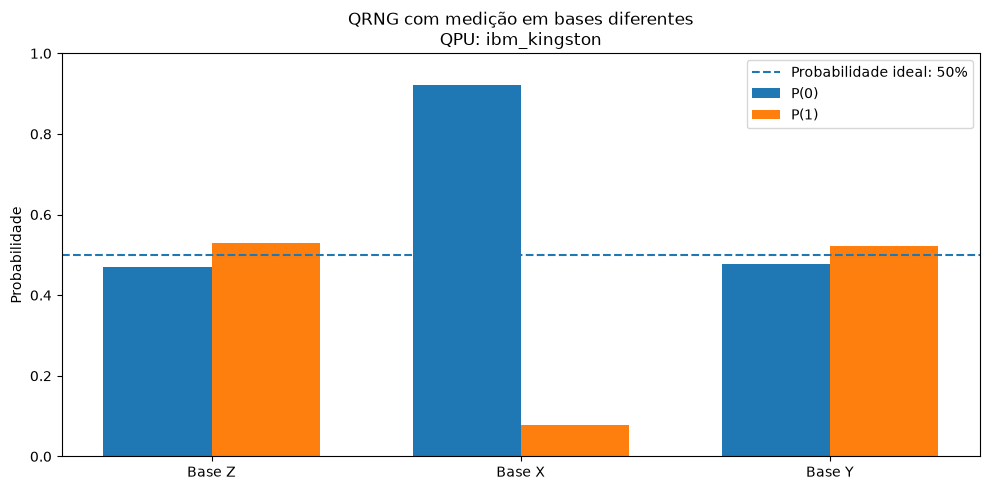

In [ ]:
from google.colab import userdata

from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

import matplotlib.pyplot as plt


#QRNG COM MEDIÇÃO EM BASES DIFERENTES


# 1. Conexão com a IBM Quantum

token_ibm = userdata.get("IBM_QUANTUM_TOKEN")
crn_ibm = userdata.get("IBM_QUANTUM_CRN")

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token_ibm,
    instance=crn_ibm
)

print("Conectado à IBM Quantum!")


# 2. Configurações

quantidade_execucoes = 1000


# 3. Escolha de uma QPU real

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=1
)

print("QPU escolhida:", backend.name)


# 4. Circuito com medição na base Z

circuito_z = QuantumCircuit(1, 1)

# Coloca o qubit em superposição
circuito_z.h(0)

# Mede diretamente na base Z
circuito_z.measure(0, 0)


# 5. Circuito com medição na base X

circuito_x = QuantumCircuit(1, 1)

# Coloca o qubit em superposição
circuito_x.h(0)

# Rotação para a base X
circuito_x.h(0)

# Medição física na base Z após a rotação
circuito_x.measure(0, 0)


# 6. Circuito com medição na base Y

circuito_y = QuantumCircuit(1, 1)

# Coloca o qubit em superposição
circuito_y.h(0)

# Rotação para a base Y
circuito_y.sdg(0)
circuito_y.h(0)

# Medição física na base Z após a rotação
circuito_y.measure(0, 0)


# 7. Transpilação dos três circuitos

pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

circuito_z_isa = pass_manager.run(circuito_z)
circuito_x_isa = pass_manager.run(circuito_x)
circuito_y_isa = pass_manager.run(circuito_y)


# 8. Execução na QPU real

sampler = SamplerV2(mode=backend)

job = sampler.run(
    [
        circuito_z_isa,
        circuito_x_isa,
        circuito_y_isa
    ],
    shots=quantidade_execucoes
)

print("ID do trabalho:", job.job_id())
print("Os três circuitos foram enviados para a QPU.")
print("Aguardando os resultados...")


# 9. Recuperação dos resultados

resultado = job.result()

bits_z = resultado[0].data.c.get_bitstrings()
bits_x = resultado[1].data.c.get_bitstrings()
bits_y = resultado[2].data.c.get_bitstrings()


# 10. Função para calcular as probabilidades

def calcular_probabilidades(bits):
    total = len(bits)

    quantidade_zeros = bits.count("0")
    quantidade_uns = bits.count("1")

    probabilidade_zero = quantidade_zeros / total
    probabilidade_um = quantidade_uns / total

    return {
        "zeros": quantidade_zeros,
        "uns": quantidade_uns,
        "p_zero": probabilidade_zero,
        "p_um": probabilidade_um
    }


resultado_z = calcular_probabilidades(bits_z)
resultado_x = calcular_probabilidades(bits_x)
resultado_y = calcular_probabilidades(bits_y)


# 11. Exibição dos resultados

print("\nBase Z:")
print("Quantidade de zeros:", resultado_z["zeros"])
print("Quantidade de uns:", resultado_z["uns"])
print(f"P(0): {resultado_z['p_zero']:.2%}")
print(f"P(1): {resultado_z['p_um']:.2%}")

print("\nBase X:")
print("Quantidade de zeros:", resultado_x["zeros"])
print("Quantidade de uns:", resultado_x["uns"])
print(f"P(0): {resultado_x['p_zero']:.2%}")
print(f"P(1): {resultado_x['p_um']:.2%}")

print("\nBase Y:")
print("Quantidade de zeros:", resultado_y["zeros"])
print("Quantidade de uns:", resultado_y["uns"])
print(f"P(0): {resultado_y['p_zero']:.2%}")
print(f"P(1): {resultado_y['p_um']:.2%}")


# 12. Gráfico comparativo

bases = ["Base Z", "Base X", "Base Y"]

probabilidades_zero = [
    resultado_z["p_zero"],
    resultado_x["p_zero"],
    resultado_y["p_zero"]
]

probabilidades_um = [
    resultado_z["p_um"],
    resultado_x["p_um"],
    resultado_y["p_um"]
]

posicoes = range(len(bases))
largura = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    [posicao - largura / 2 for posicao in posicoes],
    probabilidades_zero,
    width=largura,
    label="P(0)"
)

plt.bar(
    [posicao + largura / 2 for posicao in posicoes],
    probabilidades_um,
    width=largura,
    label="P(1)"
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Probabilidade ideal: 50%"
)

plt.xticks(list(posicoes), bases)
plt.ylabel("Probabilidade")

plt.title(
    "QRNG com medição em bases diferentes\n"
    f"QPU: {backend.name}"
)

plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

qiskit_runtime_service._discover_account:WARNING:2026-08-06 20:36:41,163: Loading account with the given token. A saved account will not be used.


Conectado à IBM Quantum!
QPU escolhida: ibm_kingston
ID do trabalho: d9qf0nnpemts73cr68j0
Circuitos enviados para a QPU IBM.
Aguardando os resultados...

Ângulo θ = 0
Quantidade de zeros: 925
Quantidade de uns: 75
P(0) experimental: 92.50%
P(1) experimental: 7.50%
P(0) teórica: 100.00%
P(1) teórica: 0.00%

Ângulo θ = π/6
Quantidade de zeros: 868
Quantidade de uns: 132
P(0) experimental: 86.80%
P(1) experimental: 13.20%
P(0) teórica: 93.30%
P(1) teórica: 6.70%

Ângulo θ = π/4
Quantidade de zeros: 790
Quantidade de uns: 210
P(0) experimental: 79.00%
P(1) experimental: 21.00%
P(0) teórica: 85.36%
P(1) teórica: 14.64%

Ângulo θ = π/2
Quantidade de zeros: 471
Quantidade de uns: 529
P(0) experimental: 47.10%
P(1) experimental: 52.90%
P(0) teórica: 50.00%
P(1) teórica: 50.00%

Ângulo θ = 3π/4
Quantidade de zeros: 188
Quantidade de uns: 812
P(0) experimental: 18.80%
P(1) experimental: 81.20%
P(0) teórica: 14.64%
P(1) teórica: 85.36%

Ângulo θ = 5π/6
Quantidade de zeros: 100
Quantidade de uns: 

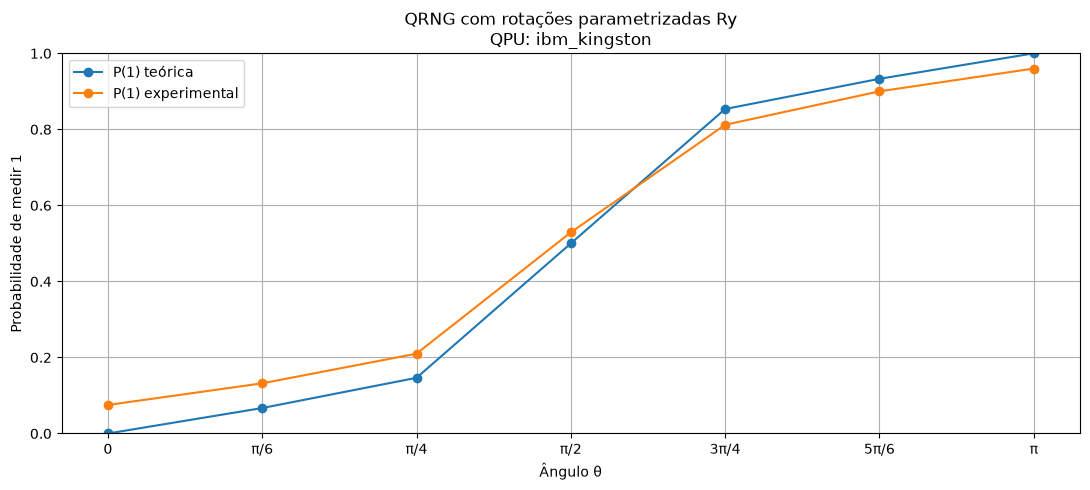

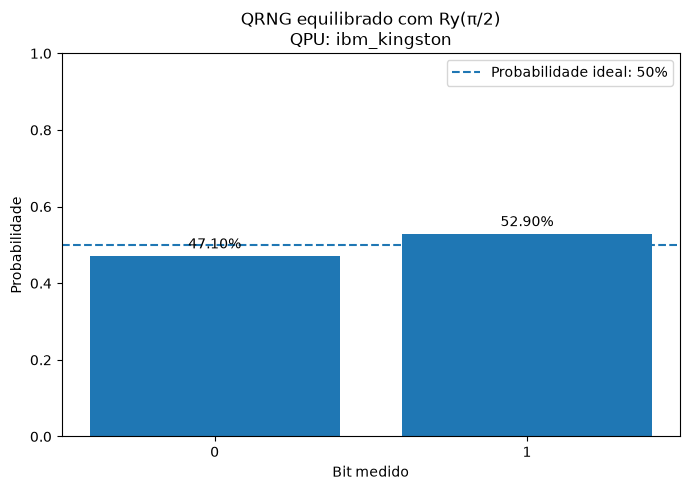

In [ ]:
from google.colab import userdata

from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

import math
import matplotlib.pyplot as plt


# ALGORITMO 4 — QRNG COM ROTAÇÕES PARAMETRIZADAS


# 1. Conexão com a IBM Quantum

token_ibm = userdata.get("IBM_QUANTUM_TOKEN")
crn_ibm = userdata.get("IBM_QUANTUM_CRN")

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token_ibm,
    instance=crn_ibm
)

print("Conectado à IBM Quantum!")


# 2. Configurações

quantidade_execucoes = 1000

angulos = [
    0,
    math.pi / 6,
    math.pi / 4,
    math.pi / 2,
    3 * math.pi / 4,
    5 * math.pi / 6,
    math.pi
]

nomes_angulos = [
    "0",
    "π/6",
    "π/4",
    "π/2",
    "3π/4",
    "5π/6",
    "π"
]


# 3. Escolha de uma QPU real

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=1
)

print("QPU escolhida:", backend.name)


# 4. Construção dos circuitos

circuitos = []

for angulo in angulos:
    circuito = QuantumCircuit(1, 1)

    # Aplica a rotação Ry no qubit 0
    circuito.ry(angulo, 0)

    # Mede o qubit
    circuito.measure(0, 0)

    circuitos.append(circuito)


# 5. Transpilação para a QPU

pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

circuitos_isa = []

for circuito in circuitos:
    circuito_isa = pass_manager.run(circuito)
    circuitos_isa.append(circuito_isa)


# 6. Execução na QPU real

sampler = SamplerV2(mode=backend)

job = sampler.run(
    circuitos_isa,
    shots=quantidade_execucoes
)

print("ID do trabalho:", job.job_id())
print("Circuitos enviados para a QPU IBM.")
print("Aguardando os resultados...")


# 7. Recuperação e análise dos resultados

probabilidades_zero_experimentais = []
probabilidades_um_experimentais = []

probabilidades_zero_teoricas = []
probabilidades_um_teoricas = []

for indice, angulo in enumerate(angulos):

    bits_medidos = (
        job.result()[indice]
        .data.c
        .get_bitstrings()
    )

    quantidade_zeros = bits_medidos.count("0")
    quantidade_uns = bits_medidos.count("1")

    probabilidade_zero = (
        quantidade_zeros / quantidade_execucoes
    )

    probabilidade_um = (
        quantidade_uns / quantidade_execucoes
    )

    probabilidade_zero_teorica = (
        math.cos(angulo / 2) ** 2
    )

    probabilidade_um_teorica = (
        math.sin(angulo / 2) ** 2
    )

    probabilidades_zero_experimentais.append(
        probabilidade_zero
    )

    probabilidades_um_experimentais.append(
        probabilidade_um
    )

    probabilidades_zero_teoricas.append(
        probabilidade_zero_teorica
    )

    probabilidades_um_teoricas.append(
        probabilidade_um_teorica
    )

    print(f"\nÂngulo θ = {nomes_angulos[indice]}")

    print("Quantidade de zeros:", quantidade_zeros)
    print("Quantidade de uns:", quantidade_uns)

    print(
        f"P(0) experimental: {probabilidade_zero:.2%}"
    )

    print(
        f"P(1) experimental: {probabilidade_um:.2%}"
    )

    print(
        f"P(0) teórica: {probabilidade_zero_teorica:.2%}"
    )

    print(
        f"P(1) teórica: {probabilidade_um_teorica:.2%}"
    )


# 8. Gráfico das probabilidades de 1

posicoes = list(range(len(angulos)))

plt.figure(figsize=(11, 5))

plt.plot(
    posicoes,
    probabilidades_um_teoricas,
    marker="o",
    label="P(1) teórica"
)

plt.plot(
    posicoes,
    probabilidades_um_experimentais,
    marker="o",
    label="P(1) experimental"
)

plt.xticks(
    posicoes,
    nomes_angulos
)

plt.title(
    "QRNG com rotações parametrizadas Ry\n"
    f"QPU: {backend.name}"
)

plt.xlabel("Ângulo θ")
plt.ylabel("Probabilidade de medir 1")
plt.ylim(0, 1)

plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


# 9. Gráfico comparativo para θ = π/2

indice_equilibrado = nomes_angulos.index("π/2")

probabilidades_equilibradas = [
    probabilidades_zero_experimentais[indice_equilibrado],
    probabilidades_um_experimentais[indice_equilibrado]
]

plt.figure(figsize=(7, 5))

barras = plt.bar(
    ["0", "1"],
    probabilidades_equilibradas
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Probabilidade ideal: 50%"
)

plt.title(
    "QRNG equilibrado com Ry(π/2)\n"
    f"QPU: {backend.name}"
)

plt.xlabel("Bit medido")
plt.ylabel("Probabilidade")
plt.ylim(0, 1)

for barra, probabilidade in zip(
    barras,
    probabilidades_equilibradas
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        probabilidade + 0.02,
        f"{probabilidade:.2%}",
        ha="center"
    )

plt.legend()
plt.tight_layout()
plt.show()

qiskit_runtime_service._discover_account:WARNING:2026-08-06 20:38:50,667: Loading account with the given token. A saved account will not be used.


Conectado à IBM Quantum!
QPU escolhida: ibm_kingston

Circuito quântico:
     ┌───┐┌─────────┐          ┌─┐              
q_0: ┤ H ├┤ Rz(π/4) ├──■───────┤M├──────────────
     ├───┤└──┬───┬──┘┌─┴─┐     └╥┘     ┌─┐      
q_1: ┤ X ├───┤ H ├───┤ X ├──■───╫──────┤M├──────
     ├───┤┌──┴───┴──┐└───┘┌─┴─┐ ║      └╥┘┌─┐   
q_2: ┤ S ├┤ Ry(π/2) ├─────┤ X ├─╫───■───╫─┤M├───
     ├───┤├─────────┤     └───┘ ║ ┌─┴─┐ ║ └╥┘┌─┐
q_3: ┤ T ├┤ Rx(π/2) ├───────────╫─┤ X ├─╫──╫─┤M├
     └───┘└─────────┘           ║ └───┘ ║  ║ └╥┘
c: 4/═══════════════════════════╩═══════╩══╩══╩═
                                0       1  2  3 

ID do trabalho: d9qf1o7pemts73cr69i0
Circuito enviado para a QPU IBM.
Aguardando o resultado...

Quantidade de medições:
1000

Primeiras 20 medições:
['0011', '0011', '1111', '0011', '1101', '1001', '1101', '0101', '1010', '1100', '0100', '1000', '1010', '1101', '1011', '1110', '1000', '1101', '0010', '0100']

Resultados:
0000: 73 ocorrências — 7.30%
0001: 74 ocorrências — 7.40%
0010:

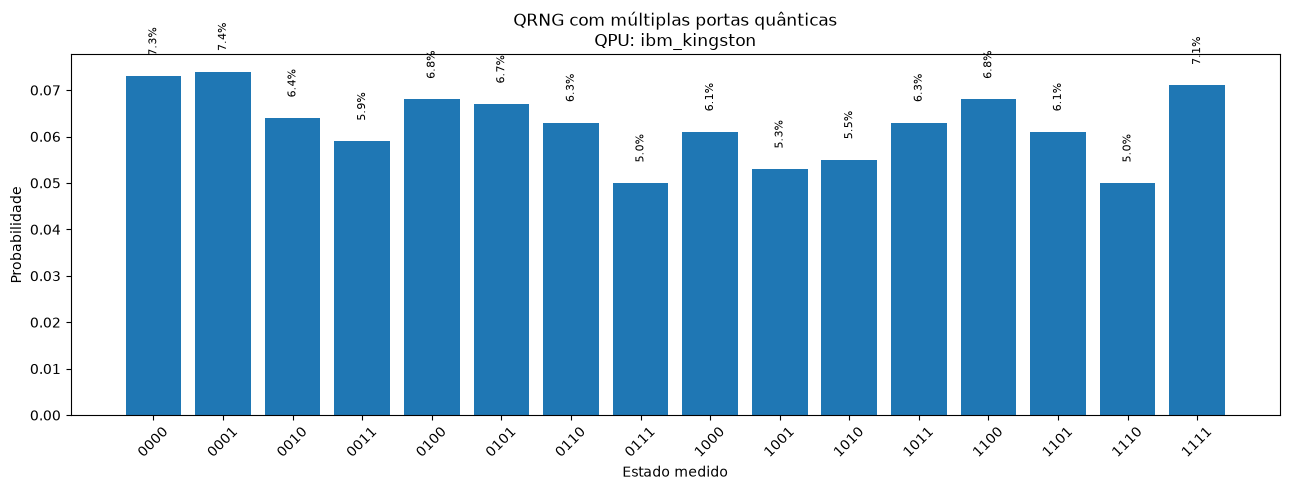

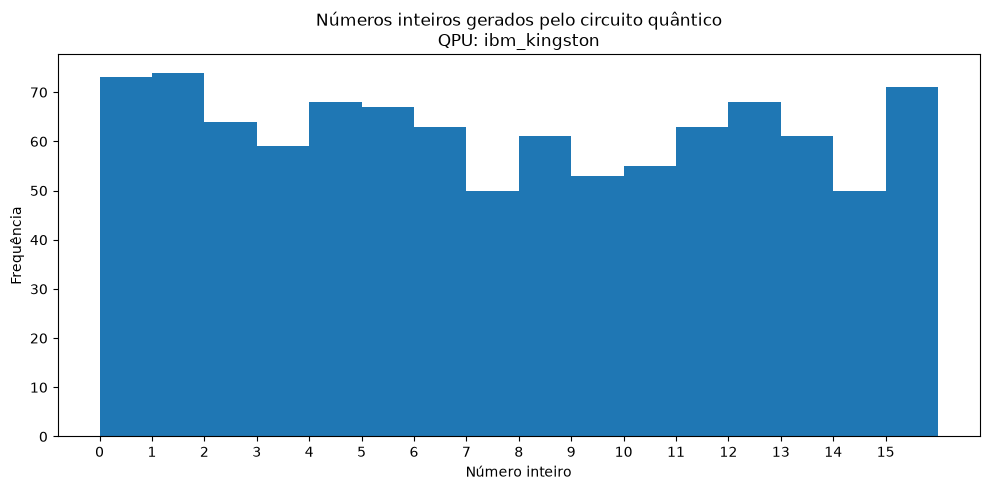

In [ ]:
from google.colab import userdata

from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

import math
import matplotlib.pyplot as plt


# QRNG COM MÚLTIPLAS PORTAS QUÂNTICAS


# Conexão com a IBM Quantum

token_ibm = userdata.get("IBM_QUANTUM_TOKEN")
crn_ibm = userdata.get("IBM_QUANTUM_CRN")

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token_ibm,
    instance=crn_ibm
)

print("Conectado à IBM Quantum!")


# Configurações

numero_qubits = 4
quantidade_execucoes = 1000


# Escolha de uma QPU real

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=numero_qubits
)

print("QPU escolhida:", backend.name)


# Construção do circuito

circuito = QuantumCircuit(
    numero_qubits,
    numero_qubits
)


# Porta Hadamard no qubit 0
circuito.h(0)

# Porta X no qubit 1
circuito.x(1)

# Porta Hadamard no qubit 1
circuito.h(1)

# Porta S no qubit 2
circuito.s(2)

# Rotação Y no qubit 2
circuito.ry(math.pi / 2, 2)

# Porta T no qubit 3
circuito.t(3)

# Rotação X no qubit 3
circuito.rx(math.pi / 2, 3)

# Rotação Z no qubit 0
circuito.rz(math.pi / 4, 0)

# Emaranhamento entre os qubits 0 e 1
circuito.cx(0, 1)

# Emaranhamento entre os qubits 1 e 2
circuito.cx(1, 2)

# Emaranhamento entre os qubits 2 e 3
circuito.cx(2, 3)

# Mede todos os qubits
circuito.measure(
    range(numero_qubits),
    range(numero_qubits)
)


# Mostra o circuito em texto

print("\nCircuito quântico:")
print(circuito.draw(output="text"))


# Transpilação para a QPU

pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

circuito_isa = pass_manager.run(circuito)


# Execução na QPU real

sampler = SamplerV2(mode=backend)

job = sampler.run(
    [circuito_isa],
    shots=quantidade_execucoes
)

print("\nID do trabalho:", job.job_id())
print("Circuito enviado para a QPU IBM.")
print("Aguardando o resultado...")


# Recuperação das medições

resultado = job.result()

sequencias_medidas = (
    resultado[0]
    .data.c
    .get_bitstrings()
)

print("\nQuantidade de medições:")
print(len(sequencias_medidas))

print("\nPrimeiras 20 medições:")
print(sequencias_medidas[:20])


# Criação de todos os resultados possíveis

estados_possiveis = [
    format(numero, f"0{numero_qubits}b")
    for numero in range(2 ** numero_qubits)
]


# Contagem dos resultados

contagens = {
    estado: sequencias_medidas.count(estado)
    for estado in estados_possiveis
}

probabilidades = {
    estado: contagens[estado] / len(sequencias_medidas)
    for estado in estados_possiveis
}


print("\nResultados:")

for estado in estados_possiveis:
    print(
        f"{estado}: "
        f"{contagens[estado]} ocorrências — "
        f"{probabilidades[estado]:.2%}"
    )


# Conversão das sequências em números inteiros

numeros_inteiros = [
    int(sequencia, 2)
    for sequencia in sequencias_medidas
]

print("\nPrimeiros 20 números inteiros:")
print(numeros_inteiros[:20])

print(
    "Quantidade de números gerados:",
    len(numeros_inteiros)
)


#  Gráfico das probabilidades

valores_grafico = [
    probabilidades[estado]
    for estado in estados_possiveis
]

plt.figure(figsize=(13, 5))

barras = plt.bar(
    estados_possiveis,
    valores_grafico
)

plt.title(
    "QRNG com múltiplas portas quânticas\n"
    f"QPU: {backend.name}"
)

plt.xlabel("Estado medido")
plt.ylabel("Probabilidade")

plt.xticks(rotation=45)

for barra, probabilidade in zip(
    barras,
    valores_grafico
):
    if probabilidade > 0:
        plt.text(
            barra.get_x() + barra.get_width() / 2,
            probabilidade + 0.005,
            f"{probabilidade:.1%}",
            ha="center",
            fontsize=8,
            rotation=90
        )

plt.tight_layout()
plt.show()


# Histograma dos números inteiros

plt.figure(figsize=(10, 5))

plt.hist(
    numeros_inteiros,
    bins=16,
    range=(0, 16)
)

plt.title(
    "Números inteiros gerados pelo circuito quântico\n"
    f"QPU: {backend.name}"
)

plt.xlabel("Número inteiro")
plt.ylabel("Frequência")

plt.xticks(range(16))
plt.tight_layout()
plt.show()

# Experimento padronizado em QPU IBM

Coleta bruta com backend e qubit físico fixos, 30 lotes × 10.000 bits, preservação dos lotes brutos, métricas e metadados de calibração.


In [ ]:

import math
import os
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels
import scipy


NUM_LOTES = 30
BITS_POR_LOTE = 10_000
ALFA = 0.05
Z_95 = 1.959963984540054

print("Python/ambiente estatístico:")
print("statsmodels:", statsmodels.__version__)
print("scipy:", scipy.__version__)


def intervalo_wilson(p, n, z=Z_95):
    if n == 0:
        return np.nan, np.nan

    denominador = 1 + (z ** 2) / n
    centro = (p + (z ** 2) / (2 * n)) / denominador
    margem = (
        z
        * math.sqrt(
            (p * (1 - p) + (z ** 2) / (4 * n))
            / n
        )
        / denominador
    )

    return centro - margem, centro + margem


def runs_test(bits):
    """
    Runs Test (Wald-Wolfowitz) usando statsmodels.

    H0: a ordem dos bits é compatível com aleatoriedade em relação
        ao número de corridas.
    H1: o número de corridas difere do esperado sob H0.

    Regra de decisão:
        p >= ALFA -> não rejeita H0
        p <  ALFA -> rejeita H0
    """
    from statsmodels.sandbox.stats.runs import runstest_1samp

    vetor = np.fromiter(
        (1 if bit == "1" else 0 for bit in bits),
        dtype=np.int8
    )

    if len(vetor) < 2 or np.all(vetor == vetor[0]):
        return np.nan, np.nan, np.nan

    numero_runs = 1 + int(np.sum(vetor[1:] != vetor[:-1]))

    z, p_valor = runstest_1samp(
        vetor,
        cutoff=0.5,
        correction=False
    )

    return numero_runs, float(z), float(p_valor)



def calcular_metricas(bits, fonte, lote, condicao="bruta"):
    bits = "".join(bits)

    n = len(bits)

    if n == 0:
        raise ValueError("O lote não contém bits.")

    zeros = bits.count("0")
    uns = bits.count("1")

    p0 = zeros / n
    p1 = uns / n

    vies = abs(p1 - 0.5)

    shannon = 0.0

    for p in (p0, p1):
        if p > 0:
            shannon -= p * math.log2(p)

    min_entropia = -math.log2(
        max(p0, p1)
    )

    vetor = np.fromiter(
        (1 if bit == "1" else 0 for bit in bits),
        dtype=np.float64
    )

    if (
        n > 1
        and np.std(vetor[:-1]) > 0
        and np.std(vetor[1:]) > 0
    ):
        autocorrelacao_lag1 = float(
            np.corrcoef(
                vetor[:-1],
                vetor[1:]
            )[0, 1]
        )
    else:
        autocorrelacao_lag1 = np.nan

    numero_runs, runs_z, runs_p_valor = runs_test(bits)

    ic95_inferior, ic95_superior = intervalo_wilson(
        p1,
        n
    )

    return {
        "fonte": fonte,
        "condicao": condicao,
        "lote": lote,
        "n_bits": n,
        "zeros": zeros,
        "uns": uns,
        "p0": p0,
        "p1": p1,
        "vies": vies,
        "ic95_p1_inferior": ic95_inferior,
        "ic95_p1_superior": ic95_superior,
        "entropia_shannon": shannon,
        "min_entropia_empirica": min_entropia,
        "autocorrelacao_lag1": autocorrelacao_lag1,
        "numero_runs": numero_runs,
        "runs_z": runs_z,
        "runs_p_valor": runs_p_valor,
        "runs_aprovado_alfa_005": (
            runs_p_valor >= ALFA
            if not np.isnan(runs_p_valor)
            else False
        ),
    }


def salvar_lote(bits, pasta, nome):
    pasta = Path(pasta)
    pasta.mkdir(
        parents=True,
        exist_ok=True
    )

    caminho = pasta / nome

    caminho.write_text(
        "".join(bits),
        encoding="utf-8"
    )

    return caminho


def resumo_metricas(df):
    colunas = [
        "p1",
        "vies",
        "entropia_shannon",
        "min_entropia_empirica",
        "autocorrelacao_lag1",
        "runs_z",
        "runs_p_valor",
    ]

    print("\nResumo dos 30 lotes:")
    display(
        df[colunas]
        .agg(["mean", "std", "min", "median", "max"])
        .T
    )

    print(
        "\nProporção de aprovação no Runs Test (alfa = 0,05):",
        f"{df['runs_aprovado_alfa_005'].mean():.2%}"
    )


# EXPERIMENTO PADRONIZADO — QPU IBM
#
# IMPORTANTE:
# 1. A QPU é FIXADA antes da coleta.
# 2. O qubit físico é FIXADO.
# 3. Não há condicionamento ou mitigação aplicado à saída bruta.
# 4. Os bits brutos de cada lote são salvos antes de qualquer pós-processamento.

from datetime import datetime, timezone
import hashlib
import platform

import qiskit
import qiskit_ibm_runtime

from google.colab import userdata
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2


FONTE = "QPU_IBM"
NOME_BACKEND = "ibm_marrakesh"
QUBIT_FISICO = 0
OPTIMIZATION_LEVEL = 0
SEED_TRANSPILER = 7

pasta_saida = Path(
    "/content/dados_padronizados/qpu_ibm"
)


# CONEXÃO

token_ibm = userdata.get(
    "IBM_QUANTUM_TOKEN"
)

crn_ibm = userdata.get(
    "IBM_QUANTUM_CRN"
)

if not token_ibm:
    raise ValueError(
        "IBM_QUANTUM_TOKEN não encontrado nos Secrets do Colab."
    )

if not crn_ibm:
    raise ValueError(
        "IBM_QUANTUM_CRN não encontrado nos Secrets do Colab."
    )

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=token_ibm,
    instance=crn_ibm
)

backend = service.backend(
    NOME_BACKEND
)

print("QPU fixa:", backend.name)
print("Qubit físico fixo:", QUBIT_FISICO)


# CIRCUITO LÓGICO:
# |0> -> H -> medição

circuito = QuantumCircuit(1, 1)
circuito.h(0)
circuito.measure(0, 0)


# TRANSPILAÇÃO FIXA

pass_manager = generate_preset_pass_manager(
    backend=backend,
    optimization_level=OPTIMIZATION_LEVEL,
    initial_layout=[QUBIT_FISICO],
    seed_transpiler=SEED_TRANSPILER
)

circuito_isa = pass_manager.run(
    circuito
)

print("\nCircuito lógico:")
print(circuito.draw(output="text"))

print("\nCircuito ISA:")
print(circuito_isa.draw(output="text"))


# SNAPSHOT DE CALIBRAÇÃO

calibracao = {
    "backend": backend.name,
    "qubit_fisico": QUBIT_FISICO,
    "coleta_iniciada_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "qiskit_version": qiskit.__version__,
    "qiskit_ibm_runtime_version": qiskit_ibm_runtime.__version__,
    "python_version": platform.python_version(),
    "optimization_level": OPTIMIZATION_LEVEL,
    "seed_transpiler": SEED_TRANSPILER,
    "num_lotes": NUM_LOTES,
    "bits_por_lote": BITS_POR_LOTE,
}

try:
    propriedades = backend.properties(
        refresh=True
    )

    if propriedades is not None:
        calibracao["t1_s"] = propriedades.t1(
            QUBIT_FISICO
        )

        calibracao["t2_s"] = propriedades.t2(
            QUBIT_FISICO
        )

        calibracao[
            "readout_error"
        ] = propriedades.readout_error(
            QUBIT_FISICO
        )

        calibracao[
            "calibration_last_update"
        ] = str(
            propriedades.last_update_date
        )

except Exception as erro:
    print(
        "Aviso: não foi possível obter todas "
        "as propriedades de calibração:",
        erro
    )

try:
    medida = backend.target[
        "measure"
    ][(QUBIT_FISICO,)]

    calibracao[
        "measurement_error_target"
    ] = getattr(
        medida,
        "error",
        None
    )

    calibracao[
        "measurement_duration_s"
    ] = getattr(
        medida,
        "duration",
        None
    )

except Exception:
    pass


# EXECUÇÃO:
# 30 PUBs idênticos no mesmo job;
# cada PUB corresponde a um lote de 10.000 medições.

sampler = SamplerV2(
    mode=backend
)

pubs = [
    circuito_isa
    for _ in range(NUM_LOTES)
]

instante_envio = datetime.now(
    timezone.utc
)

job = sampler.run(
    pubs,
    shots=BITS_POR_LOTE
)

print("\nJob ID:", job.job_id())
print("Backend:", backend.name)
print("Lotes enviados:", NUM_LOTES)
print("Shots por lote:", BITS_POR_LOTE)
print("Aguardando a QPU...")

resultado_job = job.result()

instante_resultado = datetime.now(
    timezone.utc
)

calibracao["job_id"] = job.job_id()
calibracao[
    "job_submetido_utc"
] = instante_envio.isoformat()

calibracao[
    "resultado_recebido_utc"
] = instante_resultado.isoformat()

calibracao[
    "latencia_total_cliente_s"
] = (
    instante_resultado
    - instante_envio
).total_seconds()


# PROCESSAMENTO DOS LOTES BRUTOS

resultados = []

for lote, pub_result in enumerate(
    resultado_job,
    start=1
):

    bitstrings = (
        pub_result
        .data
        .c
        .get_bitstrings()
    )

    bits = "".join(
        bitstrings
    )

    if len(bits) != BITS_POR_LOTE:
        raise ValueError(
            f"Lote {lote}: esperado "
            f"{BITS_POR_LOTE} bits, "
            f"recebidos {len(bits)}."
        )

    salvar_lote(
        bits,
        pasta_saida,
        f"qpu_bruta_lote_{lote:02d}.txt"
    )

    metricas = calcular_metricas(
        bits,
        fonte=FONTE,
        lote=lote,
        condicao="bruta"
    )

    metricas["backend"] = backend.name
    metricas[
        "qubit_fisico"
    ] = QUBIT_FISICO

    metricas["job_id"] = job.job_id()

    resultados.append(metricas)


df_qpu = pd.DataFrame(
    resultados
)

caminho_csv = (
    pasta_saida
    / "qpu_bruta_metricas_30x10000.csv"
)

df_qpu.to_csv(
    caminho_csv,
    index=False
)


# SALVA METADADOS DA COLETA

pd.DataFrame(
    [calibracao]
).to_csv(
    pasta_saida
    / "qpu_metadados_coleta.csv",
    index=False
)


print("\nColeta concluída.")
print("CSV de métricas:", caminho_csv)
print(
    "Metadados:",
    pasta_saida / "qpu_metadados_coleta.csv"
)

display(df_qpu.head())

resumo_metricas(df_qpu)


# Condicionamento da mesma saída bruta

Esta etapa não executa novamente a QPU. Ela reutiliza exatamente os lotes brutos salvos e aplica Von Neumann e SHA-256 para permitir a comparação antes/depois.


In [ ]:

import math
import os
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels
import scipy


NUM_LOTES = 30
BITS_POR_LOTE = 10_000
ALFA = 0.05
Z_95 = 1.959963984540054

print("Python/ambiente estatístico:")
print("statsmodels:", statsmodels.__version__)
print("scipy:", scipy.__version__)


def intervalo_wilson(p, n, z=Z_95):
    if n == 0:
        return np.nan, np.nan

    denominador = 1 + (z ** 2) / n
    centro = (p + (z ** 2) / (2 * n)) / denominador
    margem = (
        z
        * math.sqrt(
            (p * (1 - p) + (z ** 2) / (4 * n))
            / n
        )
        / denominador
    )

    return centro - margem, centro + margem


def runs_test(bits):
    """
    Runs Test (Wald-Wolfowitz) usando statsmodels.

    H0: a ordem dos bits é compatível com aleatoriedade em relação
        ao número de corridas.
    H1: o número de corridas difere do esperado sob H0.

    Regra de decisão:
        p >= ALFA -> não rejeita H0
        p <  ALFA -> rejeita H0
    """
    from statsmodels.sandbox.stats.runs import runstest_1samp

    vetor = np.fromiter(
        (1 if bit == "1" else 0 for bit in bits),
        dtype=np.int8
    )

    if len(vetor) < 2 or np.all(vetor == vetor[0]):
        return np.nan, np.nan, np.nan

    numero_runs = 1 + int(np.sum(vetor[1:] != vetor[:-1]))

    z, p_valor = runstest_1samp(
        vetor,
        cutoff=0.5,
        correction=False
    )

    return numero_runs, float(z), float(p_valor)



def calcular_metricas(bits, fonte, lote, condicao="bruta"):
    bits = "".join(bits)

    n = len(bits)

    if n == 0:
        raise ValueError("O lote não contém bits.")

    zeros = bits.count("0")
    uns = bits.count("1")

    p0 = zeros / n
    p1 = uns / n

    vies = abs(p1 - 0.5)

    shannon = 0.0

    for p in (p0, p1):
        if p > 0:
            shannon -= p * math.log2(p)

    min_entropia = -math.log2(
        max(p0, p1)
    )

    vetor = np.fromiter(
        (1 if bit == "1" else 0 for bit in bits),
        dtype=np.float64
    )

    if (
        n > 1
        and np.std(vetor[:-1]) > 0
        and np.std(vetor[1:]) > 0
    ):
        autocorrelacao_lag1 = float(
            np.corrcoef(
                vetor[:-1],
                vetor[1:]
            )[0, 1]
        )
    else:
        autocorrelacao_lag1 = np.nan

    numero_runs, runs_z, runs_p_valor = runs_test(bits)

    ic95_inferior, ic95_superior = intervalo_wilson(
        p1,
        n
    )

    return {
        "fonte": fonte,
        "condicao": condicao,
        "lote": lote,
        "n_bits": n,
        "zeros": zeros,
        "uns": uns,
        "p0": p0,
        "p1": p1,
        "vies": vies,
        "ic95_p1_inferior": ic95_inferior,
        "ic95_p1_superior": ic95_superior,
        "entropia_shannon": shannon,
        "min_entropia_empirica": min_entropia,
        "autocorrelacao_lag1": autocorrelacao_lag1,
        "numero_runs": numero_runs,
        "runs_z": runs_z,
        "runs_p_valor": runs_p_valor,
        "runs_aprovado_alfa_005": (
            runs_p_valor >= ALFA
            if not np.isnan(runs_p_valor)
            else False
        ),
    }


def salvar_lote(bits, pasta, nome):
    pasta = Path(pasta)
    pasta.mkdir(
        parents=True,
        exist_ok=True
    )

    caminho = pasta / nome

    caminho.write_text(
        "".join(bits),
        encoding="utf-8"
    )

    return caminho


def resumo_metricas(df):
    colunas = [
        "p1",
        "vies",
        "entropia_shannon",
        "min_entropia_empirica",
        "autocorrelacao_lag1",
        "runs_z",
        "runs_p_valor",
    ]

    print("\nResumo dos 30 lotes:")
    display(
        df[colunas]
        .agg(["mean", "std", "min", "median", "max"])
        .T
    )

    print(
        "\nProporção de aprovação no Runs Test (alfa = 0,05):",
        f"{df['runs_aprovado_alfa_005'].mean():.2%}"
    )


# CONDICIONAMENTO PADRONIZADO DA MESMA SAÍDA BRUTA DA QPU
#
# Esta célula NÃO executa novamente a QPU.
# Ela lê exatamente os lotes brutos salvos pela célula anterior.

import hashlib


def extrator_von_neumann(bits):
    saida = []

    for indice in range(
        0,
        len(bits) - 1,
        2
    ):
        par = bits[
            indice:indice + 2
        ]

        if par == "01":
            saida.append("0")

        elif par == "10":
            saida.append("1")

    return "".join(saida)


def bits_para_bytes(bits):
    tamanho_util = (
        len(bits) // 8
    ) * 8

    bits = bits[:tamanho_util]

    if not bits:
        return b""

    return int(
        bits,
        2
    ).to_bytes(
        len(bits) // 8,
        byteorder="big"
    )


def condicionamento_sha256(
    bits,
    tamanho_bloco=1024
):
    if tamanho_bloco % 8 != 0:
        raise ValueError(
            "tamanho_bloco deve ser múltiplo de 8."
        )

    quantidade_blocos = (
        len(bits) // tamanho_bloco
    )

    saida = []

    for indice in range(
        quantidade_blocos
    ):
        inicio = (
            indice
            * tamanho_bloco
        )

        bloco = bits[
            inicio:
            inicio + tamanho_bloco
        ]

        bloco_bytes = bits_para_bytes(
            bloco
        )

        digest = hashlib.sha256(
            bloco_bytes
        ).digest()

        saida.append(
            "".join(
                format(byte, "08b")
                for byte in digest
            )
        )

    return "".join(saida)


pasta_saida = Path(
    "/content/dados_padronizados/qpu_ibm"
)

resultados_condicionados = []

for lote in range(
    1,
    NUM_LOTES + 1
):
    caminho_bruto = (
        pasta_saida
        / f"qpu_bruta_lote_{lote:02d}.txt"
    )

    if not caminho_bruto.exists():
        raise FileNotFoundError(
            f"Arquivo ausente: {caminho_bruto}. "
            "Execute primeiro a célula de coleta padronizada da QPU."
        )

    bits_brutos = caminho_bruto.read_text(
        encoding="utf-8"
    ).strip()

    # 1. Von Neumann
    bits_vn = extrator_von_neumann(
        bits_brutos
    )

    salvar_lote(
        bits_vn,
        pasta_saida,
        f"qpu_von_neumann_lote_{lote:02d}.txt"
    )

    if bits_vn:
        metricas_vn = calcular_metricas(
            bits_vn,
            fonte="QPU_IBM",
            lote=lote,
            condicao="von_neumann"
        )

        metricas_vn[
            "taxa_util"
        ] = len(bits_vn) / len(
            bits_brutos
        )

        resultados_condicionados.append(
            metricas_vn
        )

    # 2. SHA-256 exploratório: 1024 bits -> 256 bits
    bits_sha = condicionamento_sha256(
        bits_brutos,
        tamanho_bloco=1024
    )

    salvar_lote(
        bits_sha,
        pasta_saida,
        f"qpu_sha256_lote_{lote:02d}.txt"
    )

    if bits_sha:
        metricas_sha = calcular_metricas(
            bits_sha,
            fonte="QPU_IBM",
            lote=lote,
            condicao="sha256_1024_para_256"
        )

        metricas_sha[
            "taxa_util"
        ] = len(bits_sha) / len(
            bits_brutos
        )

        resultados_condicionados.append(
            metricas_sha
        )


df_qpu_condicionado = pd.DataFrame(
    resultados_condicionados
)

caminho_csv = (
    pasta_saida
    / "qpu_condicionamento_metricas.csv"
)

df_qpu_condicionado.to_csv(
    caminho_csv,
    index=False
)

print(
    "Condicionamento concluído sem nova execução da QPU."
)

print(
    "CSV:",
    caminho_csv
)

display(
    df_qpu_condicionado.head()
)

print("\nResumo por condição:")

display(
    df_qpu_condicionado
    .groupby("condicao")[
        [
            "n_bits",
            "p1",
            "vies",
            "entropia_shannon",
            "min_entropia_empirica",
            "autocorrelacao_lag1",
            "taxa_util",
        ]
    ]
    .agg(["mean", "std", "min", "max"])
)


# Comparação estatística inferencial entre as quatro fontes

Esta etapa utiliza os 30 lotes de cada fonte já salvos em CSV.

São aplicados:

- **Kruskal–Wallis** para verificar diferenças globais entre PRNG, CSPRNG, simulador e QPU;
- **epsilon-quadrado (ε²)** como tamanho de efeito do Kruskal–Wallis;
- **Mann–Whitney U** nas comparações par a par quando o teste global é significativo;
- **correção de Holm** para os valores-p das comparações múltiplas;
- **correlação bisserial de postos** como tamanho de efeito nas comparações par a par.

A análise é aplicada às métricas `p1`, viés, entropia de Shannon, min-entropia empírica e autocorrelação com defasagem 1.

> Execute primeiro os quatro experimentos padronizados para gerar os respectivos arquivos CSV.


In [ ]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import scipy
import statsmodels

from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests


ALFA = 0.05

print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)


def localizar_csv(nome, candidatos):
    for pasta in candidatos:
        caminho = Path(pasta) / nome
        if caminho.exists():
            return caminho

    # Também procura recursivamente no /content, útil no Google Colab.
    for raiz in [Path("/content"), Path.cwd()]:
        if raiz.exists():
            encontrados = list(raiz.rglob(nome))
            if encontrados:
                return encontrados[0]

    raise FileNotFoundError(
        f"Não foi possível localizar {nome}. "
        "Execute o notebook correspondente ou envie o CSV para o ambiente."
    )


candidatos = [
    ".",
    "/content",
    "/content/dados_padronizados/prng",
    "/content/dados_padronizados/csprng",
    "/content/dados_padronizados/simulador",
    "/content/dados_padronizados/qpu",
]

arquivos_metricas = {
    "PRNG": "prng_metricas_30x10000.csv",
    "CSPRNG": "csprng_metricas_30x10000.csv",
    "Simulador": "simulador_metricas_30x10000.csv",
    "QPU": "qpu_bruta_metricas_30x10000.csv",
}

dfs = {}

for fonte, nome_csv in arquivos_metricas.items():
    caminho = localizar_csv(nome_csv, candidatos)
    dfs[fonte] = pd.read_csv(caminho)
    print(f"{fonte}: {caminho} ({len(dfs[fonte])} lotes)")


metricas = {
    "P(1)": "p1",
    "Viés": "vies",
    "Entropia de Shannon": "entropia_shannon",
    "Min-entropia empírica": "min_entropia_empirica",
    "Autocorrelação (lag 1)": "autocorrelacao_lag1",
}


def epsilon_quadrado_kruskal(H, n_total, k):
    if n_total <= k:
        return np.nan
    return max(0.0, (H - k + 1) / (n_total - k))


def rank_biserial(U, n1, n2):
    # Sinal depende da ordem dos grupos; magnitude mede o tamanho do efeito.
    return 1 - (2 * U) / (n1 * n2)


resultados_globais = []
resultados_pares = []

for nome_metrica, coluna in metricas.items():
    grupos = {}

    for fonte, df in dfs.items():
        valores = pd.to_numeric(df[coluna], errors="coerce").dropna().to_numpy()
        grupos[fonte] = valores

    H, p_global = kruskal(*grupos.values())

    n_total = sum(len(v) for v in grupos.values())
    k = len(grupos)
    eps2 = epsilon_quadrado_kruskal(H, n_total, k)

    resultados_globais.append({
        "metrica": nome_metrica,
        "estatistica_H": H,
        "p_valor": p_global,
        "epsilon_quadrado": eps2,
        "significativo_alfa_005": p_global < ALFA,
    })

    # Pós-teste somente quando o teste global é significativo.
    if p_global < ALFA:
        pares = []
        p_brutos = []
        info = []

        for fonte1, fonte2 in combinations(grupos.keys(), 2):
            x = grupos[fonte1]
            y = grupos[fonte2]

            U, p = mannwhitneyu(
                x,
                y,
                alternative="two-sided",
                method="auto"
            )

            efeito = rank_biserial(U, len(x), len(y))

            pares.append((fonte1, fonte2))
            p_brutos.append(p)
            info.append((U, efeito))

        rejeitar, p_holm, _, _ = multipletests(
            p_brutos,
            alpha=ALFA,
            method="holm"
        )

        for (fonte1, fonte2), p_bruto, p_corrigido, rejeita, (U, efeito) in zip(
            pares, p_brutos, p_holm, rejeitar, info
        ):
            resultados_pares.append({
                "metrica": nome_metrica,
                "comparacao": f"{fonte1} × {fonte2}",
                "U": U,
                "p_bruto": p_bruto,
                "p_holm": p_corrigido,
                "rank_biserial": efeito,
                "significativo_apos_holm": bool(rejeita),
            })


df_kruskal = pd.DataFrame(resultados_globais)
df_pares = pd.DataFrame(resultados_pares)

print("\nKruskal–Wallis entre as quatro fontes:")
display(df_kruskal)

if len(df_pares):
    print("\nComparações par a par (Mann–Whitney + Holm):")
    display(df_pares)
else:
    print("\nNenhuma métrica apresentou diferença global significativa; "
          "não foram necessários pós-testes par a par.")


# Salva os resultados para rastreabilidade.
saida = Path("/content/dados_padronizados/comparacao_estatistica")
saida.mkdir(parents=True, exist_ok=True)

df_kruskal.to_csv(
    saida / "kruskal_wallis_fontes.csv",
    index=False
)

df_pares.to_csv(
    saida / "mannwhitney_holm_fontes.csv",
    index=False
)

print("\nArquivos salvos em:", saida)
